Matthew Tankersley

CS 7830 Machine Learning

Final Project - Predicting Obesity Levels

The goal of my paper is to see if I can calculate a participants level of obesity when excluding the two features used to calculate that obesity. My dataset has 16 features and 1 multiclass. The multiclass is level of obesity (0 ~ 6). Of the 16 features, 2 were used to calculate the level of obesity they are weight and height (Body Mass Index). These two features will be removed from my dataset.

Import Everything for the Final Project.

In [73]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import label_binarize, StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.inspection import permutation_importance

The following dataset will be used for this report. This is the website I got the dataset from and the article discussing it indepth.

Reference: https://www.sciencedirect.com/science/article/pii/S2352340919306985

Reference: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

Load the data into a pandas dataframe

In [74]:
#Reference: https://www.geeksforgeeks.org/python/python-os-getcwd-method/

#Load the dataset
#Get the current working directory you are in
cwd = os.getcwd()

#Creates the path to my data file
path = os.path.join(cwd,"ObesityDataSet.csv")

#Read the obesity dataset and assign it to a variable
ObesityDataSetCsv = pd.read_csv(path)

EDA: Exploratory Data Analysis Section

Review details about the data. How many rows and columns does it have. What does the data itself look like.

In [75]:
#Print out the obesity dataset dimensions and review what the data looks like by viewing the first few rows
print("Rows, Columns\n", ObesityDataSetCsv.shape)
print("----------------------")
print("The first five rows:\n", ObesityDataSetCsv.head())

Rows, Columns
 (2111, 17)
----------------------
The first five rows:
    Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public

Deep dive into the individual features. How much of each value exist for the individual features. What are the number of participants, number of unique classes, most frequent class, and number of most frequent class.

In [76]:
#Reference: https://www.geeksforgeeks.org/pandas/python-pandas-series-value_counts/
#Reference: https://www.geeksforgeeks.org/pandas/python-pandas-dataframe-describe-method/

#Print information about the individual features
#I did it this way because I like the formatting better
print("count: number of participants") 
print("unique: number of unique classes")
print("top: most frequent class")
print("freq: number of most frequent class")
print("****************************************")
print(ObesityDataSetCsv['Age'].value_counts(ascending=False))
print(ObesityDataSetCsv['Age'].describe())
print("***************Height*************************")
print(ObesityDataSetCsv['Height'].value_counts(ascending=False))
print(ObesityDataSetCsv['Height'].describe())
print("****************************************")
print(ObesityDataSetCsv['Weight'].value_counts(ascending=False))
print(ObesityDataSetCsv['Weight'].describe())
print("****************************************")
print(ObesityDataSetCsv['family_history_with_overweight'].value_counts(ascending=False))
print(ObesityDataSetCsv['family_history_with_overweight'].describe())
print("****************************************")
print(ObesityDataSetCsv['FAVC'].value_counts(ascending=False))
print(ObesityDataSetCsv['FAVC'].describe())
print("****************************************")
print(ObesityDataSetCsv['FCVC'].value_counts(ascending=False))
print(ObesityDataSetCsv['FCVC'].describe())
print("****************************************")
print(ObesityDataSetCsv['NCP'].value_counts(ascending=False))
print(ObesityDataSetCsv['NCP'].describe())
print("****************************************")
print(ObesityDataSetCsv['CAEC'].value_counts(ascending=False))
print(ObesityDataSetCsv['CAEC'].describe())
print("****************************************")
print(ObesityDataSetCsv['SMOKE'].value_counts(ascending=False))
print(ObesityDataSetCsv['SMOKE'].describe())
print("****************************************")
print(ObesityDataSetCsv['CH2O'].value_counts(ascending=False))
print(ObesityDataSetCsv['CH2O'].describe())
print("****************************************")
print(ObesityDataSetCsv['SCC'].value_counts(ascending=False))
print(ObesityDataSetCsv['SCC'].describe())
print("****************************************")
print(ObesityDataSetCsv['FAF'].value_counts(ascending=False))
print(ObesityDataSetCsv['FAF'].describe())
print("****************************************")
print(ObesityDataSetCsv['TUE'].value_counts(ascending=False))
print(ObesityDataSetCsv['TUE'].describe())
print("****************************************")
print(ObesityDataSetCsv['CALC'].value_counts(ascending=False))
print(ObesityDataSetCsv['CALC'].describe())
print("****************************************")
print(ObesityDataSetCsv['MTRANS'].value_counts(ascending=False))
print(ObesityDataSetCsv['MTRANS'].describe())
print("****************************************")
print(ObesityDataSetCsv['NObeyesdad'].value_counts(ascending=False))
print(ObesityDataSetCsv['NObeyesdad'].describe())

count: number of participants
unique: number of unique classes
top: most frequent class
freq: number of most frequent class
****************************************
Age
18.000000    128
26.000000    101
21.000000     96
23.000000     89
19.000000     59
            ... 
20.976842      1
21.982942      1
22.524036      1
24.361936      1
23.664709      1
Name: count, Length: 1402, dtype: int64
count    2111.000000
mean       24.312600
std         6.345968
min        14.000000
25%        19.947192
50%        22.777890
75%        26.000000
max        61.000000
Name: Age, dtype: float64
***************Height*************************
Height
1.700000    60
1.650000    50
1.600000    43
1.750000    39
1.620000    36
            ..
1.710730     1
1.748584     1
1.752206     1
1.739450     1
1.738836     1
Name: count, Length: 1574, dtype: int64
count    2111.000000
mean        1.701677
std         0.093305
min         1.450000
25%         1.630000
50%         1.700499
75%         1.768464
max 

Create a bar graph to visualize the distribution in each feature

In [77]:
#Reference: https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/
#Reference: https://codesignal.com/learn/courses/introduction-to-basic-plots-with-matplotlib/lessons/creating-bar-charts-with-matplotlib

#Takes in the individual feature
def createBarGraph(feature):

    #Collect the amount of each value for that feature. Ascending = False prevents the graph from being in ascending order so ordered data is preserved. Otherwise low, mid, high might end up mid, low, high.
    featureInfo = feature.value_counts(ascending=False)

    #The raw information being graphed
    print("The value for each entry is:\n", featureInfo)
    print("------------------------------------")
    print("More statistics about the feature:\n", feature.describe())
    
    #Set the size in inches
    plt.figure(figsize=(20,5))

    #Set the X and Y axis. Set the color to red because my favorite color is red.
    plt.bar(featureInfo.index, featureInfo, color='red')

    #Set the name to use the feature
    plt.title(feature.name)

    #Prints the graph to the screen
    plt.show()

Review feature dispersion and feature information for every feature

The value for each entry is:
 Gender
Male      1068
Female    1043
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count     2111
unique       2
top       Male
freq      1068
Name: Gender, dtype: object


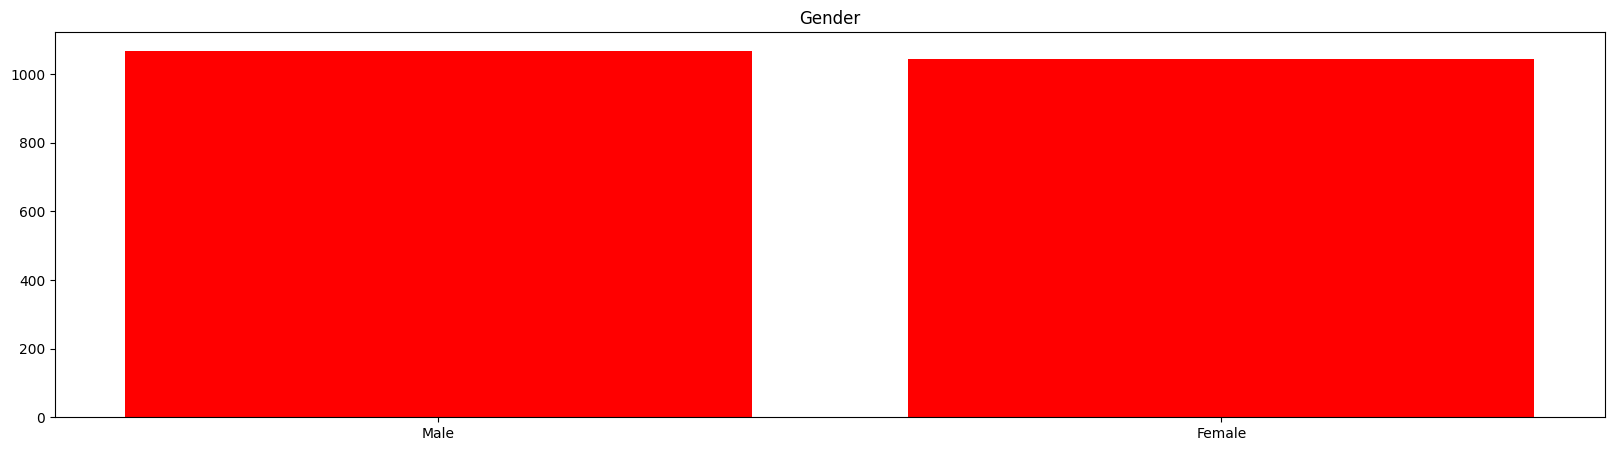

In [78]:
#Male or Female 
createBarGraph(ObesityDataSetCsv['Gender'])

The value for each entry is:
 Age
18.000000    128
26.000000    101
21.000000     96
23.000000     89
19.000000     59
            ... 
20.976842      1
21.982942      1
22.524036      1
24.361936      1
23.664709      1
Name: count, Length: 1402, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean       24.312600
std         6.345968
min        14.000000
25%        19.947192
50%        22.777890
75%        26.000000
max        61.000000
Name: Age, dtype: float64


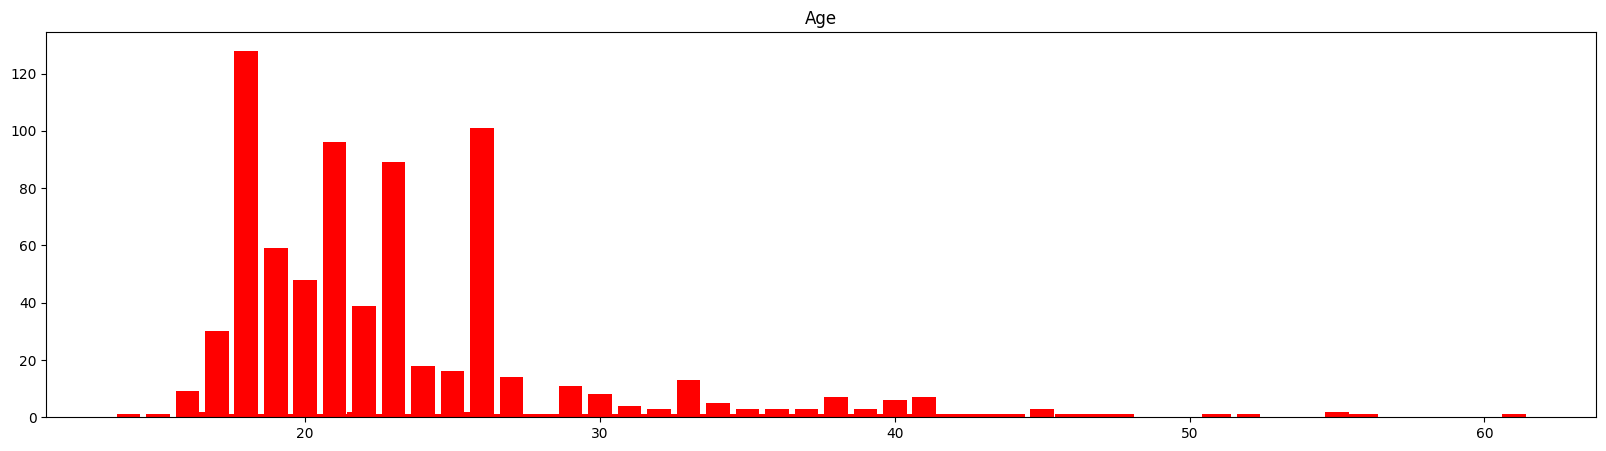

In [79]:
#Age is in years
createBarGraph(ObesityDataSetCsv['Age'])

The value for each entry is:
 Height
1.700000    60
1.650000    50
1.600000    43
1.750000    39
1.620000    36
            ..
1.710730     1
1.748584     1
1.752206     1
1.739450     1
1.738836     1
Name: count, Length: 1574, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean        1.701677
std         0.093305
min         1.450000
25%         1.630000
50%         1.700499
75%         1.768464
max         1.980000
Name: Height, dtype: float64


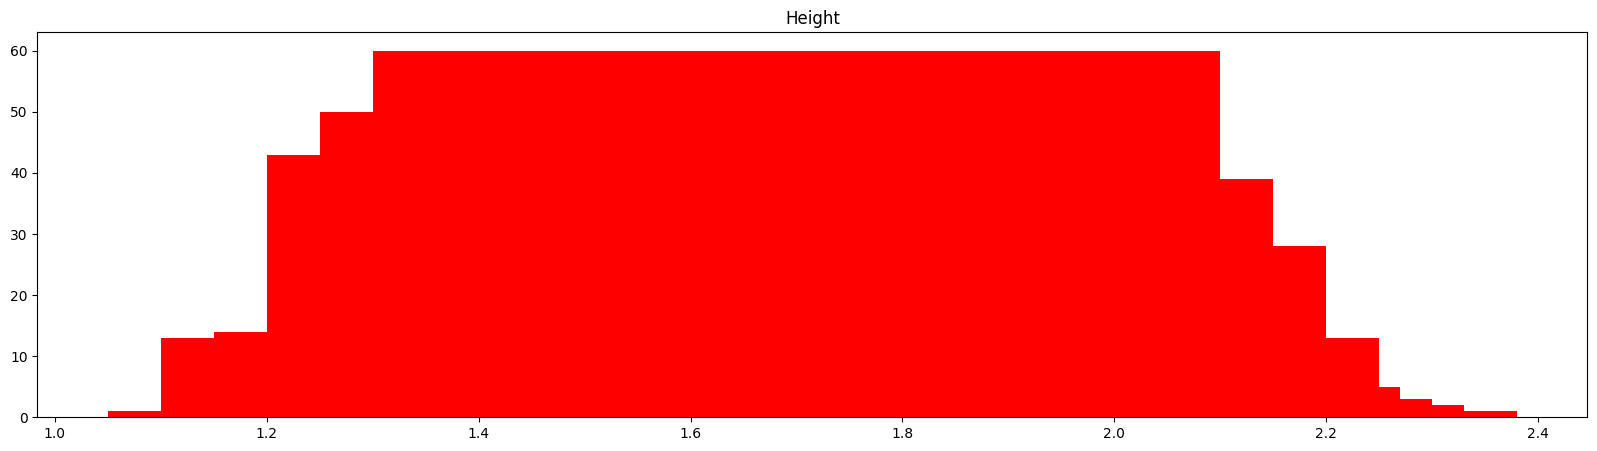

In [80]:
#Height value is in Meters, 1 meter = roughly 40 inches or 3 feet
createBarGraph(ObesityDataSetCsv['Height'])

The value for each entry is:
 Weight
80.000000     59
70.000000     43
50.000000     42
75.000000     40
60.000000     37
              ..
131.408528     1
133.742943     1
133.689352     1
133.346641     1
133.472641     1
Name: count, Length: 1525, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean       86.586058
std        26.191172
min        39.000000
25%        65.473343
50%        83.000000
75%       107.430682
max       173.000000
Name: Weight, dtype: float64


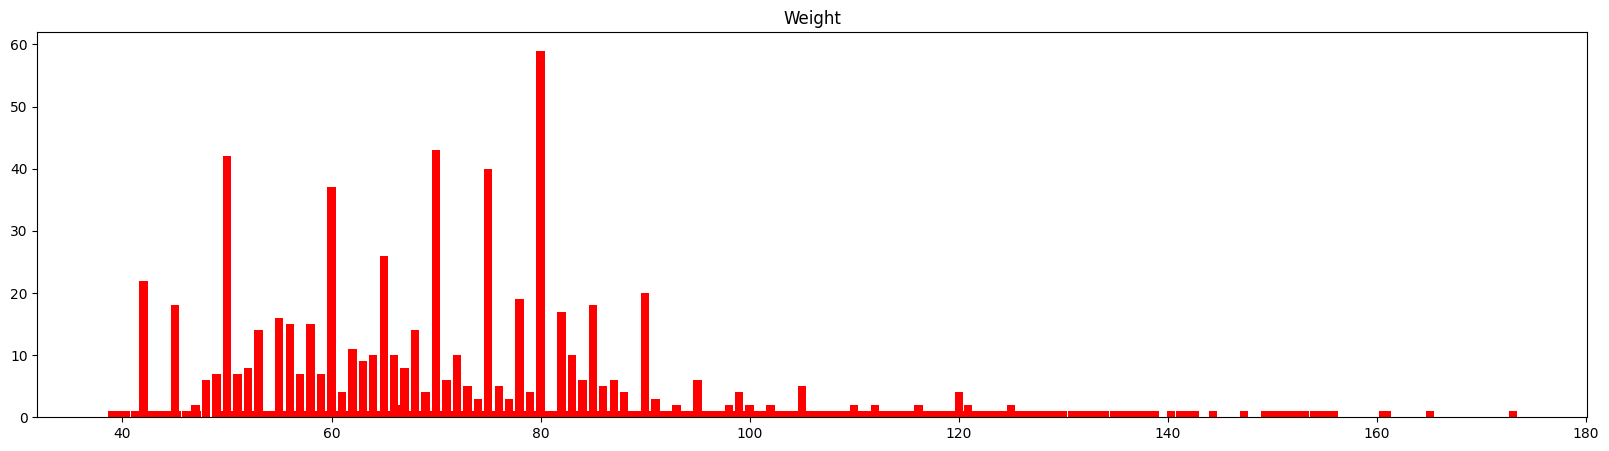

In [81]:
#Weight is in kilograms; 1 kilogram = 2.2 pounds
createBarGraph(ObesityDataSetCsv['Weight'])

The value for each entry is:
 family_history_with_overweight
yes    1726
no      385
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count     2111
unique       2
top        yes
freq      1726
Name: family_history_with_overweight, dtype: object


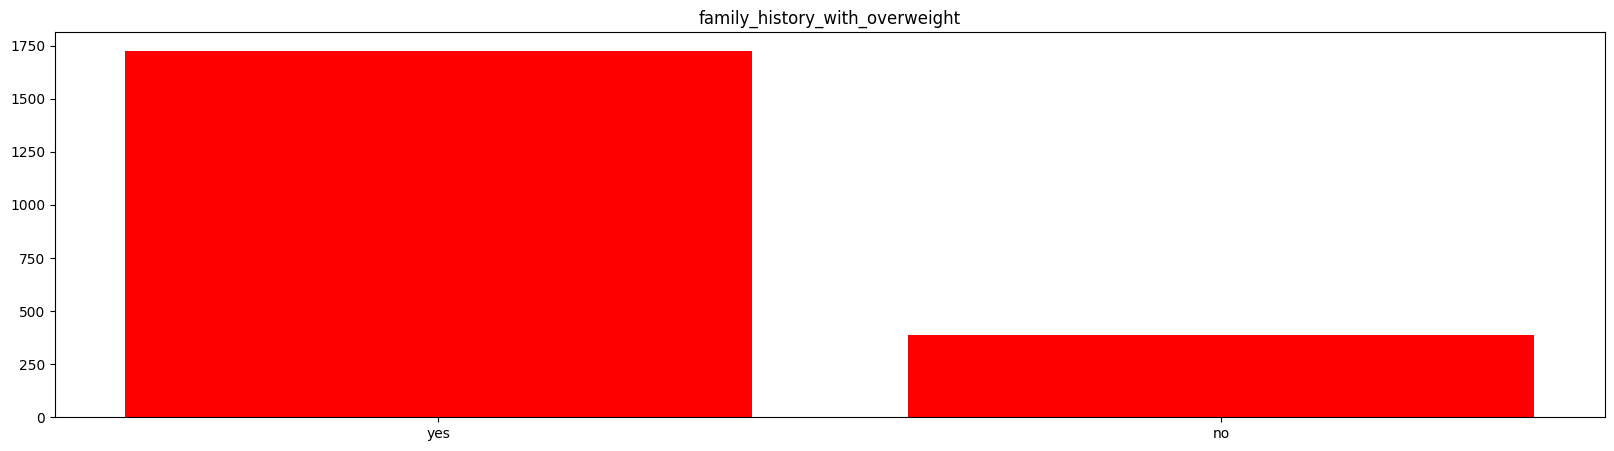

In [82]:
#Does a family member have a history of being overwight
createBarGraph(ObesityDataSetCsv['family_history_with_overweight'])

The value for each entry is:
 FAVC
yes    1866
no      245
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count     2111
unique       2
top        yes
freq      1866
Name: FAVC, dtype: object


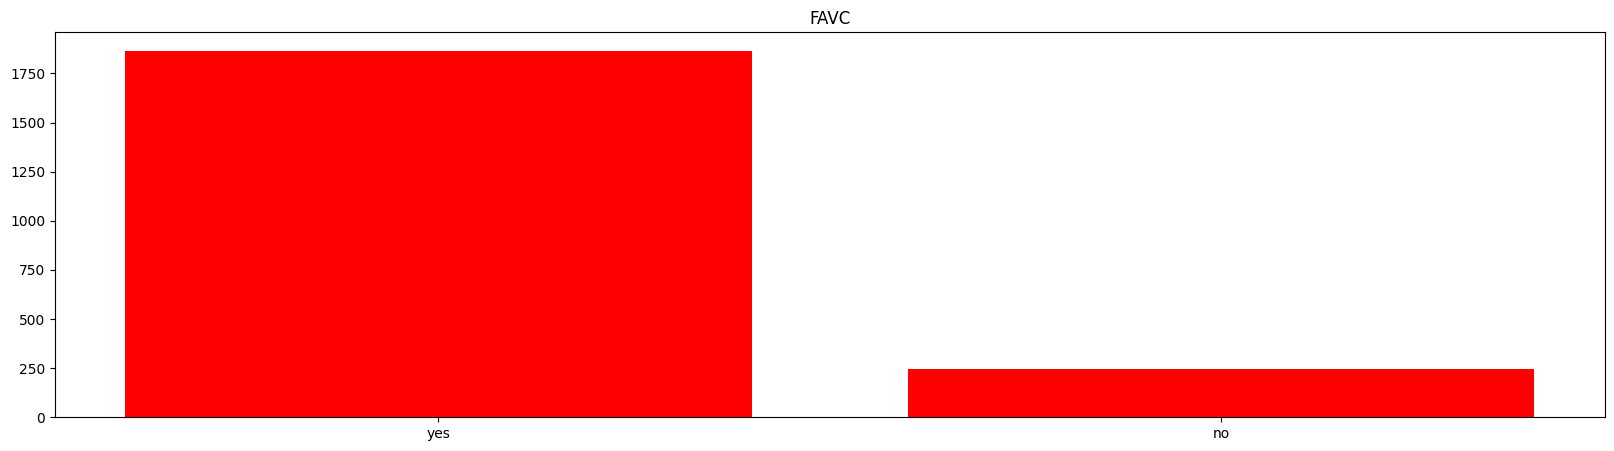

In [83]:
#Do you eat food with high calories often
createBarGraph(ObesityDataSetCsv['FAVC'])

The value for each entry is:
 FCVC
3.000000    652
2.000000    600
1.000000     33
2.392665      2
2.714447      2
           ... 
2.919526      1
2.724121      1
2.801992      1
2.748971      1
2.680375      1
Name: count, Length: 810, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean        2.419043
std         0.533927
min         1.000000
25%         2.000000
50%         2.385502
75%         3.000000
max         3.000000
Name: FCVC, dtype: float64


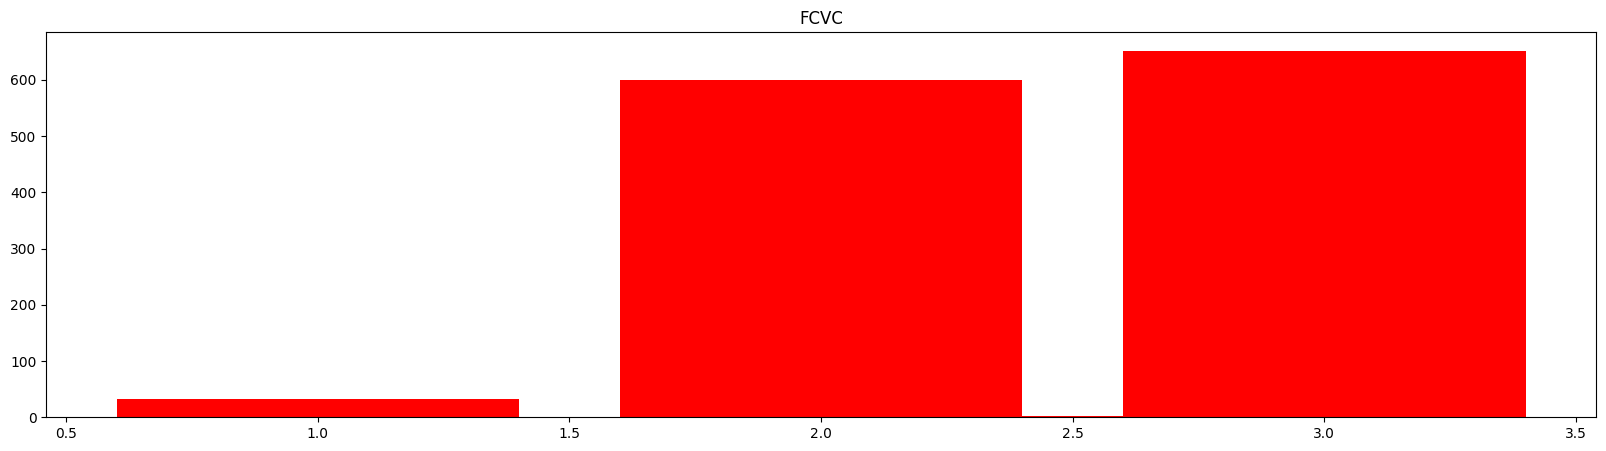

In [84]:
#Do you eat vegetables often
createBarGraph(ObesityDataSetCsv['FCVC'])

The value for each entry is:
 NCP
3.000000    1203
1.000000     199
4.000000      69
1.737620       2
1.894384       2
            ... 
2.142328       1
1.437959       1
1.343117       1
1.213431       1
1.089048       1
Name: count, Length: 635, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean        2.685628
std         0.778039
min         1.000000
25%         2.658738
50%         3.000000
75%         3.000000
max         4.000000
Name: NCP, dtype: float64


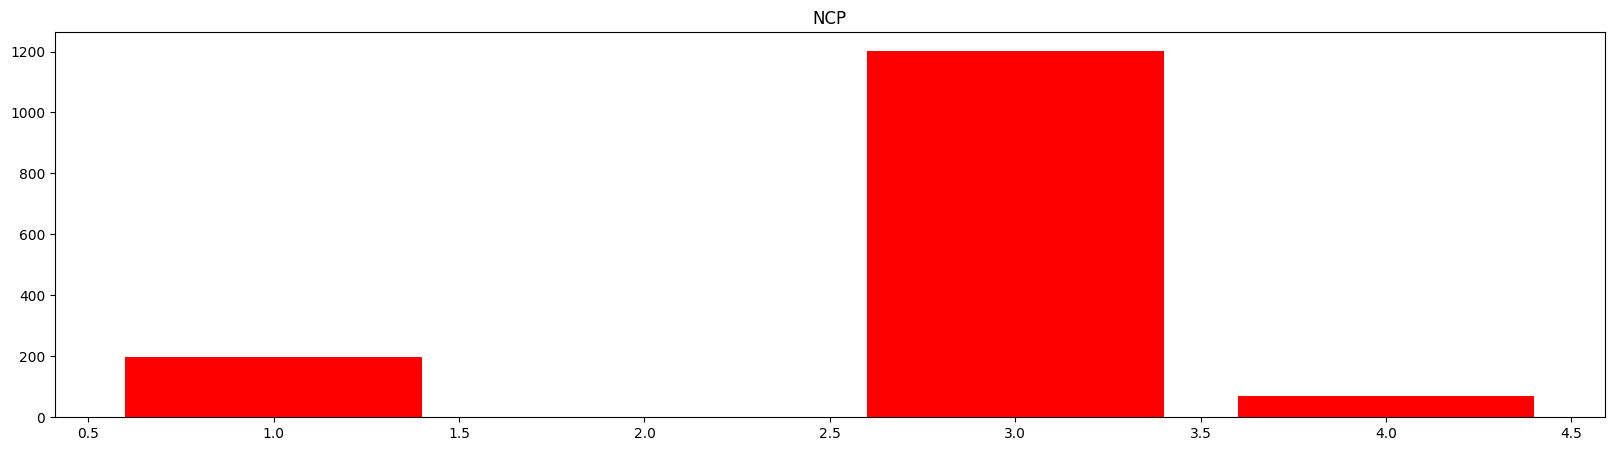

In [85]:
#Number of Meals you eat each day
createBarGraph(ObesityDataSetCsv['NCP'])

The value for each entry is:
 CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count          2111
unique            4
top       Sometimes
freq           1765
Name: CAEC, dtype: object


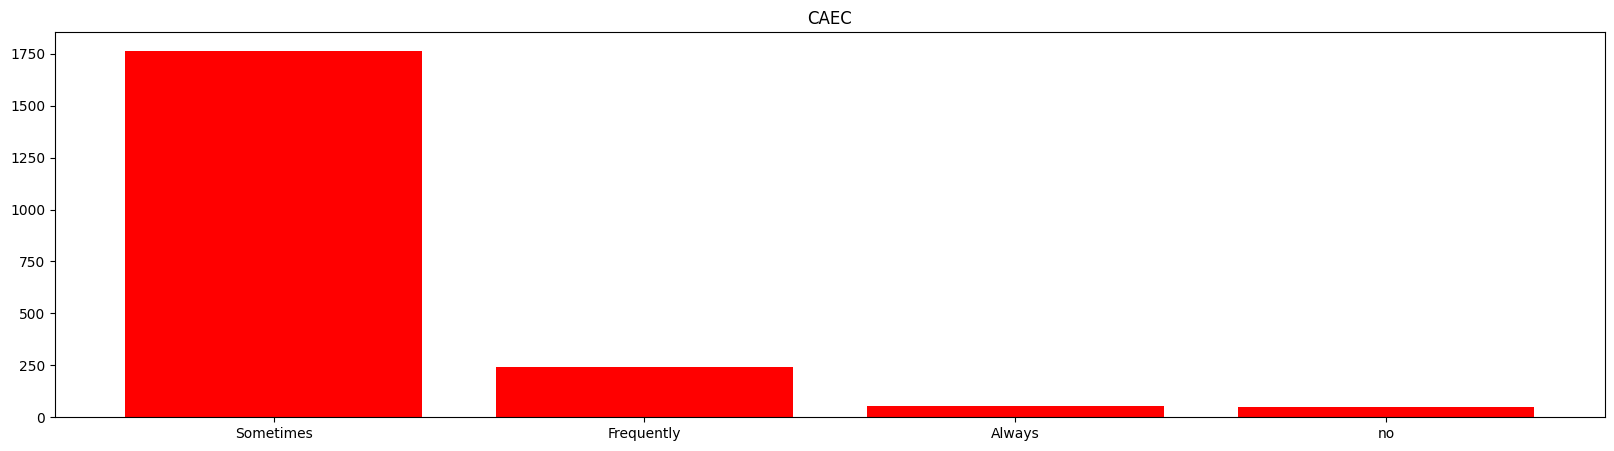

In [86]:
#Do you snack
createBarGraph(ObesityDataSetCsv['CAEC'])

The value for each entry is:
 SMOKE
no     2067
yes      44
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count     2111
unique       2
top         no
freq      2067
Name: SMOKE, dtype: object


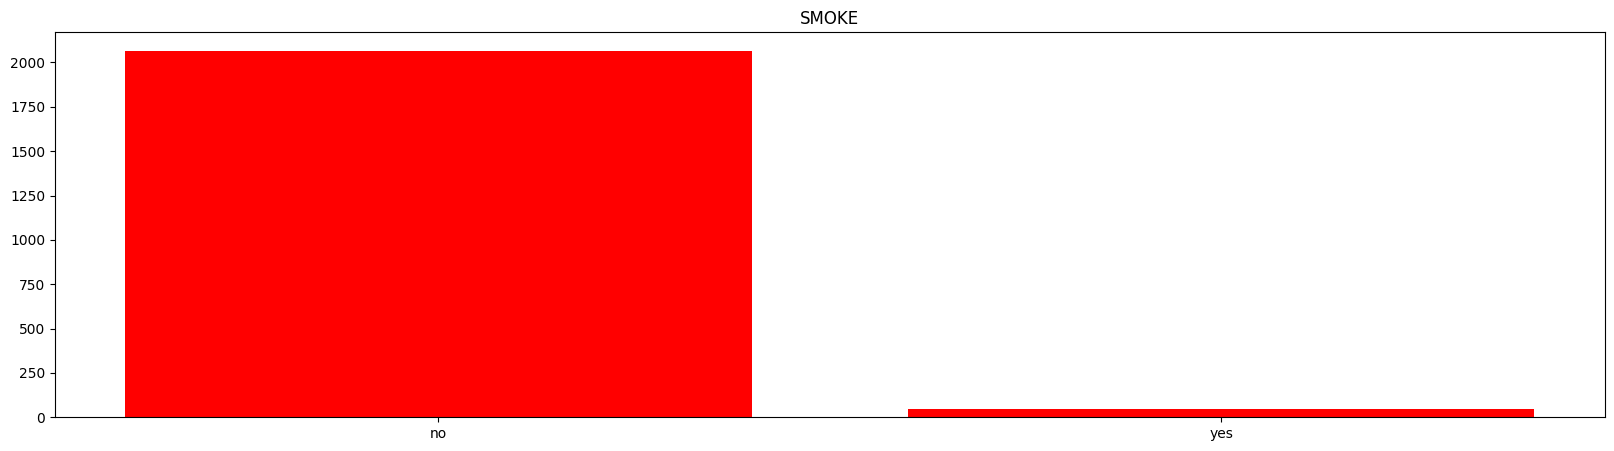

In [87]:
#Do you smoke
createBarGraph(ObesityDataSetCsv['SMOKE'])

The value for each entry is:
 CH2O
2.000000    448
1.000000    211
3.000000    162
2.825629      3
1.636326      3
           ... 
1.728139      1
2.005130      1
2.054193      1
2.852339      1
2.863513      1
Name: count, Length: 1268, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean        2.008011
std         0.612953
min         1.000000
25%         1.584812
50%         2.000000
75%         2.477420
max         3.000000
Name: CH2O, dtype: float64


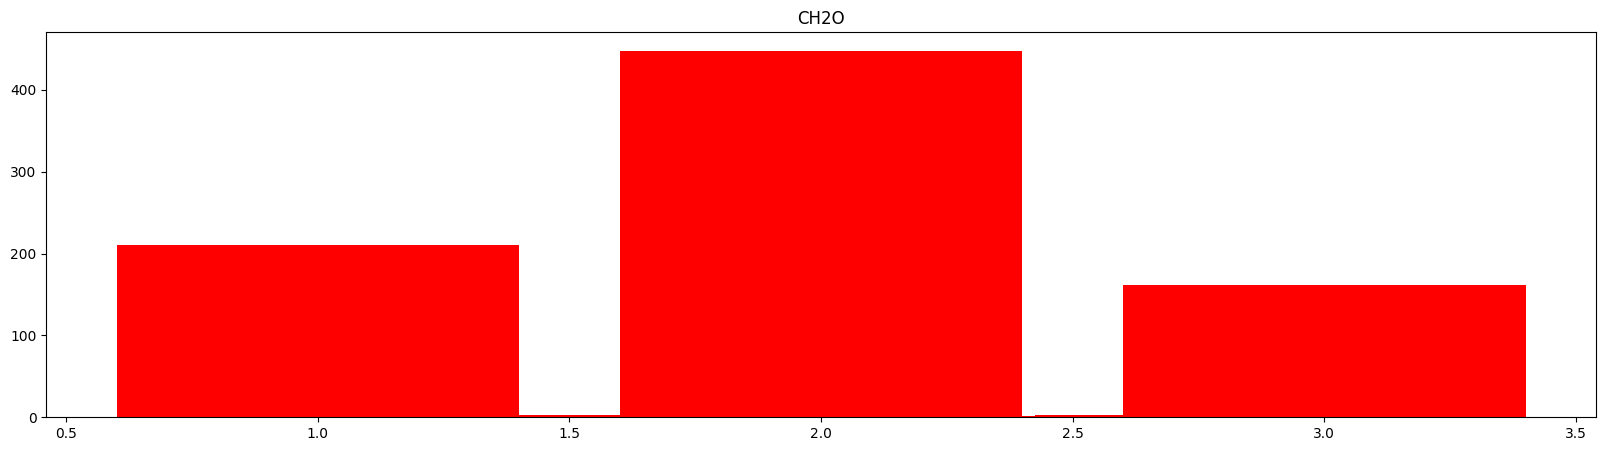

In [88]:
#How much water do you drink in a day, in liters. 1 liter = roughly 34 oz
createBarGraph(ObesityDataSetCsv['CH2O'])

The value for each entry is:
 SCC
no     2015
yes      96
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count     2111
unique       2
top         no
freq      2015
Name: SCC, dtype: object


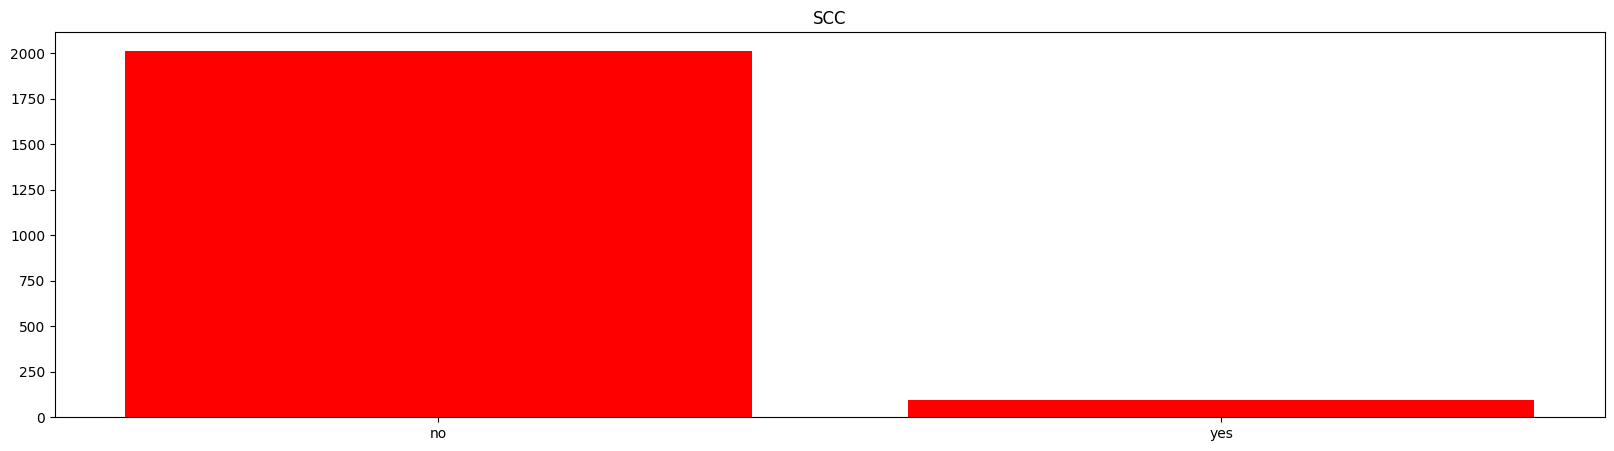

In [89]:
#Do you pay attention to the number of calories you eat daily
createBarGraph(ObesityDataSetCsv['SCC'])

The value for each entry is:
 FAF
0.000000    411
1.000000    234
2.000000    183
3.000000     75
1.541072      2
           ... 
1.676269      1
1.341390      1
1.414209      1
1.139107      1
1.026452      1
Name: count, Length: 1190, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean        1.010298
std         0.850592
min         0.000000
25%         0.124505
50%         1.000000
75%         1.666678
max         3.000000
Name: FAF, dtype: float64


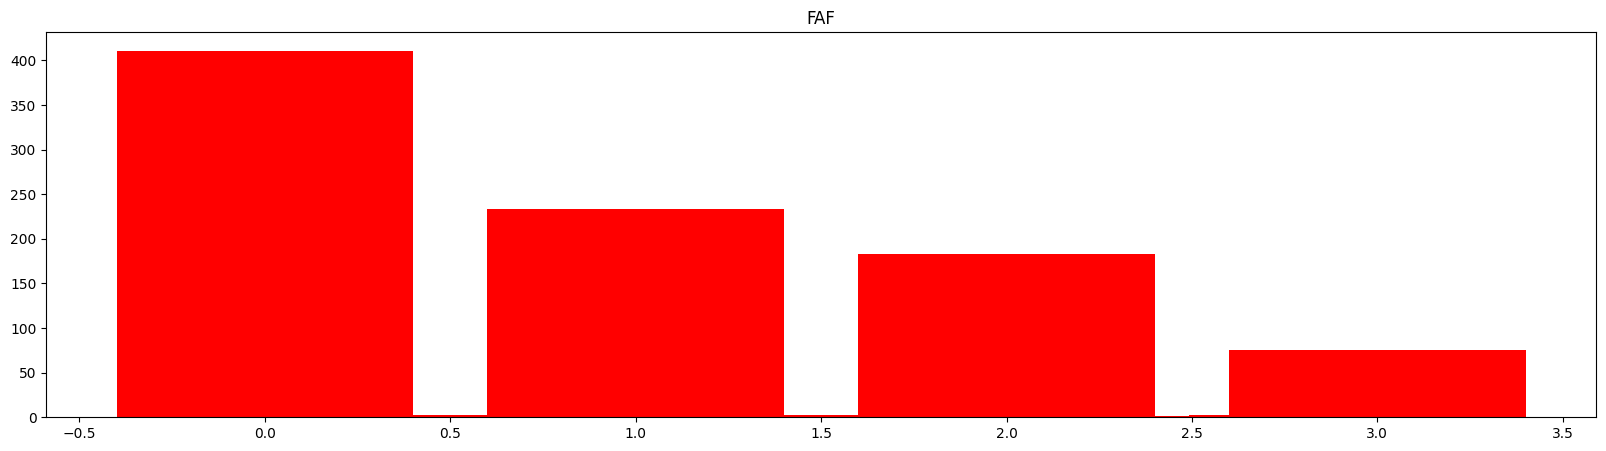

In [90]:
#How often do you work out.
createBarGraph(ObesityDataSetCsv['FAF'])

The value for each entry is:
 TUE
0.000000    557
1.000000    292
2.000000    109
0.630866      4
1.119877      3
           ... 
0.906247      1
0.599270      1
0.646288      1
0.586035      1
0.714137      1
Name: count, Length: 1129, dtype: int64
------------------------------------
More statistics about the feature:
 count    2111.000000
mean        0.657866
std         0.608927
min         0.000000
25%         0.000000
50%         0.625350
75%         1.000000
max         2.000000
Name: TUE, dtype: float64


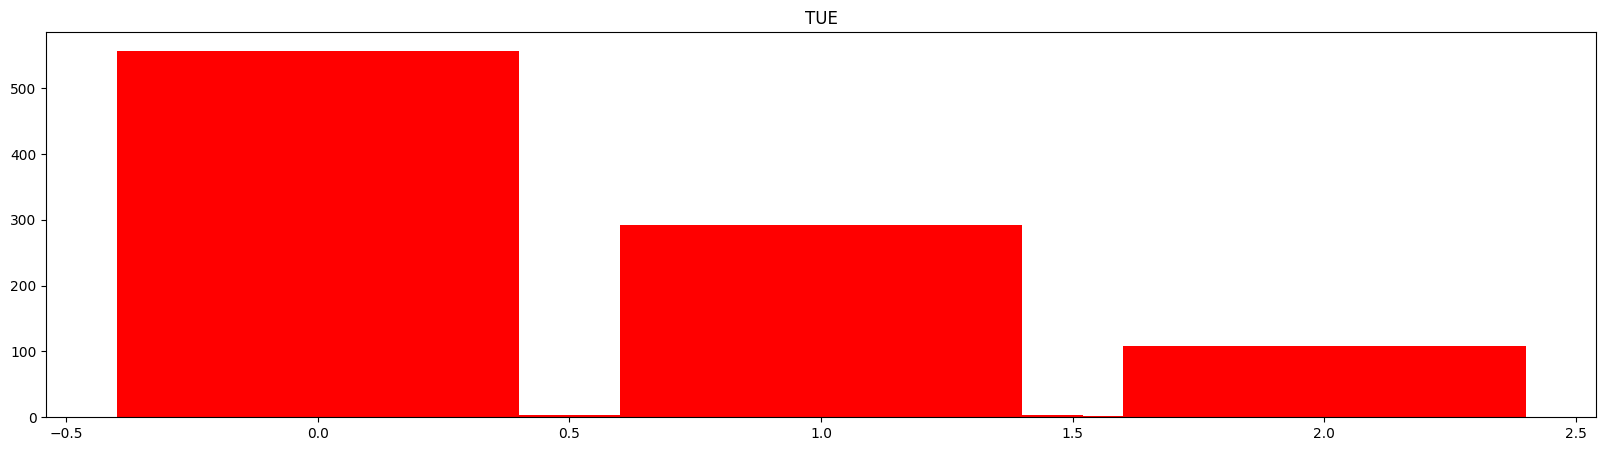

In [91]:
#How much time in hours a day do you use technology
createBarGraph(ObesityDataSetCsv['TUE'])

The value for each entry is:
 CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count          2111
unique            4
top       Sometimes
freq           1401
Name: CALC, dtype: object


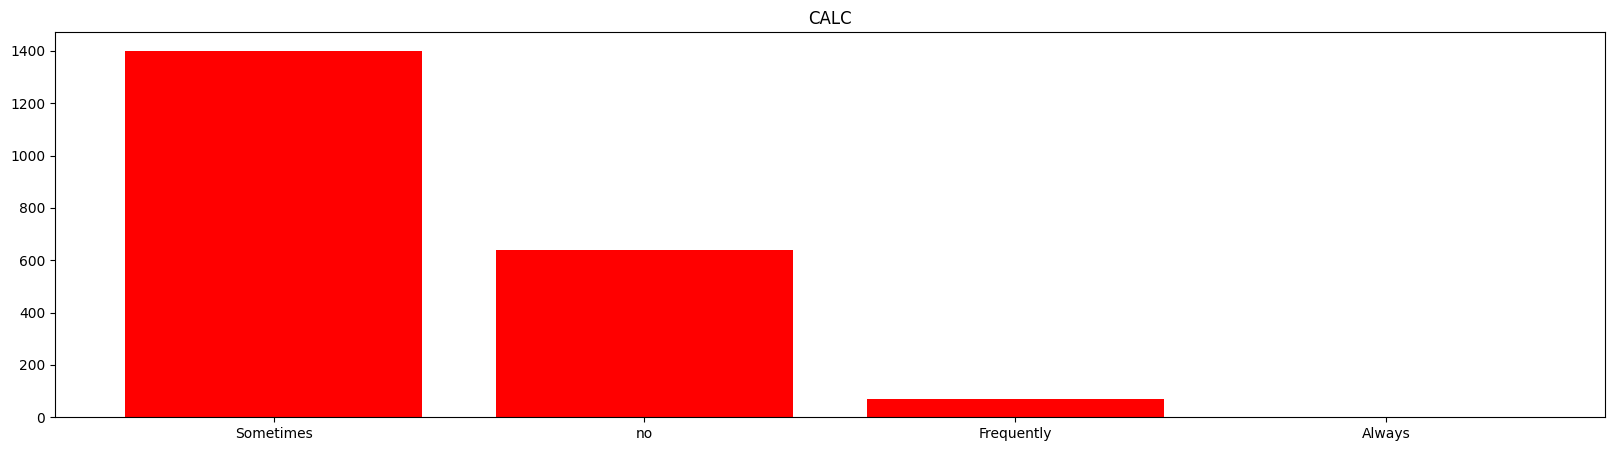

In [92]:
#How often do you drink alcohol
createBarGraph(ObesityDataSetCsv['CALC'])

The value for each entry is:
 MTRANS
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count                      2111
unique                        5
top       Public_Transportation
freq                       1580
Name: MTRANS, dtype: object


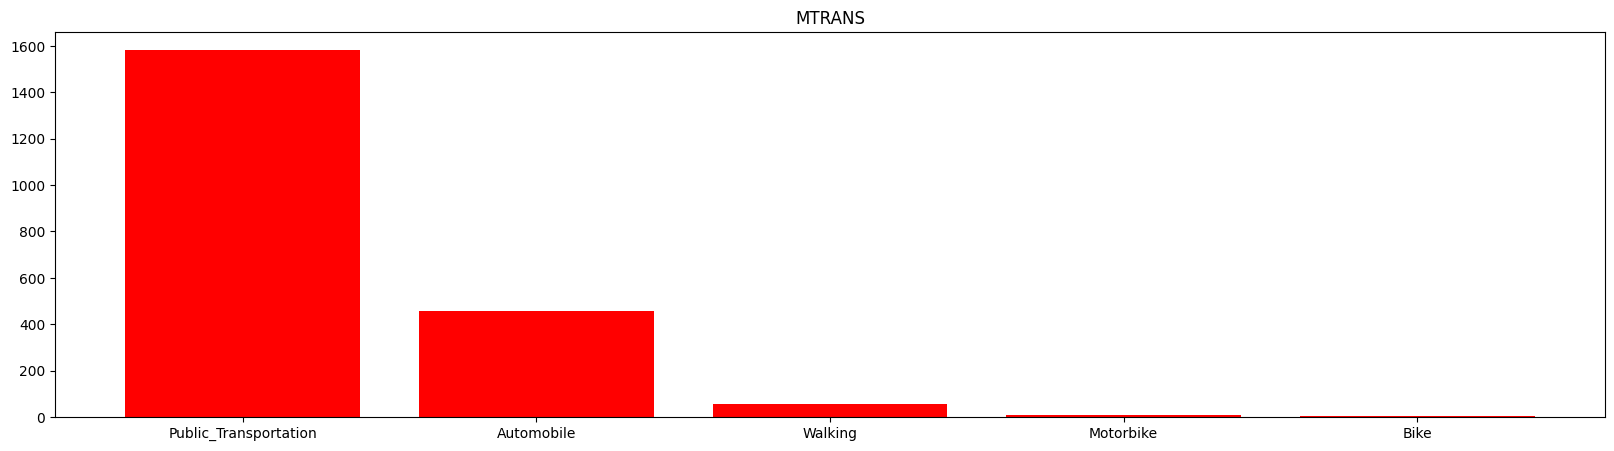

In [93]:
#What is your primary mode of transportion
createBarGraph(ObesityDataSetCsv['MTRANS'])

This feature is the target class.

The value for each entry is:
 NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64
------------------------------------
More statistics about the feature:
 count               2111
unique                 7
top       Obesity_Type_I
freq                 351
Name: NObeyesdad, dtype: object


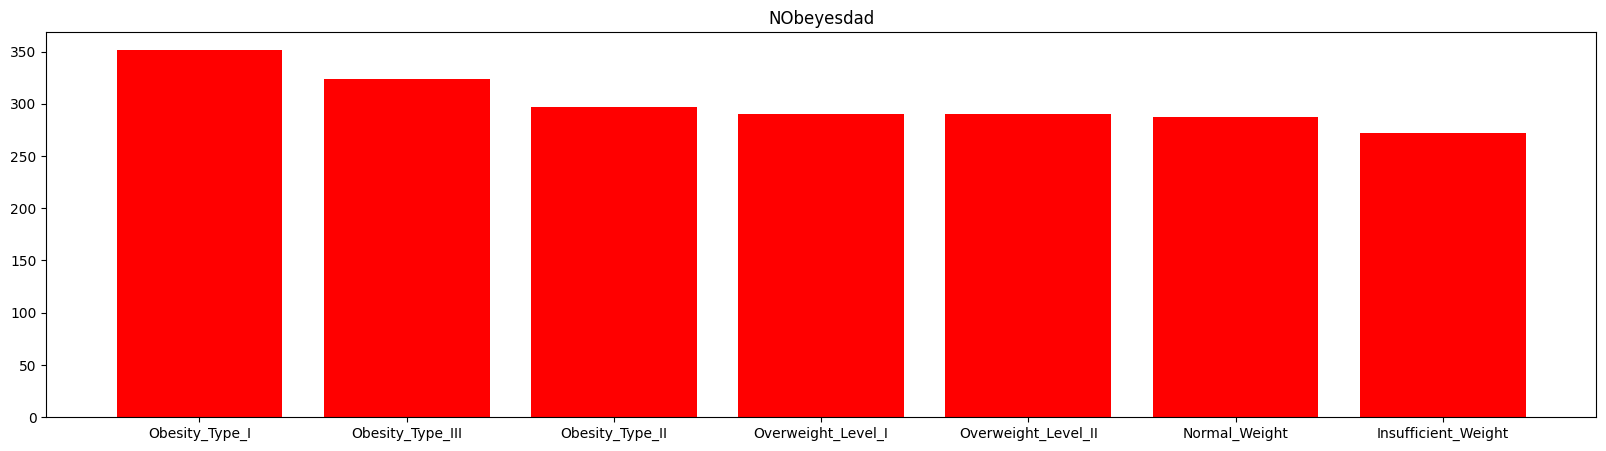

In [94]:
#Targert Class with 7 outcomes
createBarGraph(ObesityDataSetCsv['NObeyesdad'])

Encode the data by replacing string data with numbers. The first section is binary data. The second portion is ordinal data (ranked data).

In [95]:
#Reference: https://www.geeksforgeeks.org/python/how-to-convert-categorical-variable-to-numeric-in-pandas/
#Reference: https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/

#Everything needs converted into a float/int in order to work with the models being built
#I will set all of the binary features to 0 and 1. The change is permenant
ObesityDataSetCsv['Gender'] = ObesityDataSetCsv['Gender'].replace(['Female', 'Male'], [0, 1])
ObesityDataSetCsv['family_history_with_overweight'] = ObesityDataSetCsv['family_history_with_overweight'].replace(['no', 'yes'], [0, 1])
ObesityDataSetCsv['FAVC'] = ObesityDataSetCsv['FAVC'].replace(['no', 'yes'], [0, 1])
ObesityDataSetCsv['SMOKE'] = ObesityDataSetCsv['SMOKE'].replace(['no', 'yes'], [0, 1])
ObesityDataSetCsv['SCC'] = ObesityDataSetCsv['SCC'].replace(['no', 'yes'], [0, 1])

#Set the ordered features from 0 ~ # where 0 is the lowest instance of the feature
ObesityDataSetCsv['CAEC'] = ObesityDataSetCsv['CAEC'].replace(['no', 'Sometimes', 'Frequently', 'Always'], [0, 1, 2, 3])
ObesityDataSetCsv['CALC'] = ObesityDataSetCsv['CALC'].replace(['no', 'Sometimes', 'Frequently', 'Always'], [0, 1, 2, 3])
#Convert the target class
ObesityDataSetCsv['NObeyesdad'] = ObesityDataSetCsv['NObeyesdad'].replace(['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 
                                                                           'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'], [0, 1, 2, 3, 4, 5, 6])

#Uses One Hot Encoding, this splits the categorical data into individual binary colums where 1 is if that column was true and 0 for all other options.
ObesityDataSetCsv = pd.get_dummies(ObesityDataSetCsv, columns=['MTRANS'], dtype=int)

Make sure all the features actually updated.

In [96]:
#print the encoded features
print(ObesityDataSetCsv[['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'CAEC', 'CALC', 'NObeyesdad', 'MTRANS_Public_Transportation', 'MTRANS_Automobile', 'MTRANS_Walking', 'MTRANS_Motorbike', 'MTRANS_Bike']])

     Gender family_history_with_overweight FAVC SMOKE SCC CAEC CALC  \
0         0                              1    0     0   0    1    0   
1         0                              1    0     1   1    1    1   
2         1                              1    0     0   0    1    2   
3         1                              0    0     0   0    1    2   
4         1                              0    0     0   0    1    1   
...     ...                            ...  ...   ...  ..  ...  ...   
2106      0                              1    1     0   0    1    1   
2107      0                              1    1     0   0    1    1   
2108      0                              1    1     0   0    1    1   
2109      0                              1    1     0   0    1    1   
2110      0                              1    1     0   0    1    1   

     NObeyesdad  MTRANS_Public_Transportation  MTRANS_Automobile  \
0             1                             1                  0   
1          

Feature Scale the data so all values are between the same range.

In [ ]:
#Reference: https://www.geeksforgeeks.org/pandas/python-scaling-numbers-column-by-column-with-pandas/
#Reference: https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/

#This is the scaler we will be applying to the data, from my understanding this scaler is best for Logistic Regression and Neural Networks. Both used in this code.
#Scales the data around 0 with standard deviation of 1.
scalerInstance = StandardScaler()
#scalerInstance = MinMaxScaler() #See last cell in this code to see an example of the minmaxscalar and the lower metrics it provides.

#Only non binary columns need to be scaled {Age, Height, Weight, FCVC, NCP, CAEC, CH2O, FAF, TUE, CALC}
#These are the remianing features that have not gone through encoding in the previous cell
ObesityDataSetCsv[["Age", "Height", "Weight", "FCVC", "NCP", "CAEC", "CH2O", "FAF", "TUE", "CALC"]] = scalerInstance.fit_transform(
    ObesityDataSetCsv[["Age", "Height", "Weight", "FCVC", "NCP", "CAEC", "CH2O", "FAF", "TUE", "CALC"]])

#Print to confirm that the data has been scaled.
print(ObesityDataSetCsv)

     Gender       Age    Height    Weight family_history_with_overweight FAVC  \
0         0 -0.522124 -0.875589 -0.862558                              1    0   
1         0 -0.522124 -1.947599 -1.168077                              1    0   
2         1 -0.206889  1.054029 -0.366090                              1    0   
3         1  0.423582  1.054029  0.015808                              0    0   
4         1 -0.364507  0.839627  0.122740                              0    0   
...     ...       ...       ...       ...                            ...  ...   
2106      0 -0.525774  0.097045  1.711763                              1    1   
2107      0 -0.367195  0.502844  1.800914                              1    1   
2108      0 -0.281909  0.541672  1.798868                              1    1   
2109      0  0.007776  0.404927  1.785780                              1    1   
2110      0 -0.102119  0.398344  1.790592                              1    1   

          FCVC       NCP   

Correlation Matrix, use this to review each features correlation with eachother. Pay specific attention to the correlation with the target class "NObeyesdad".

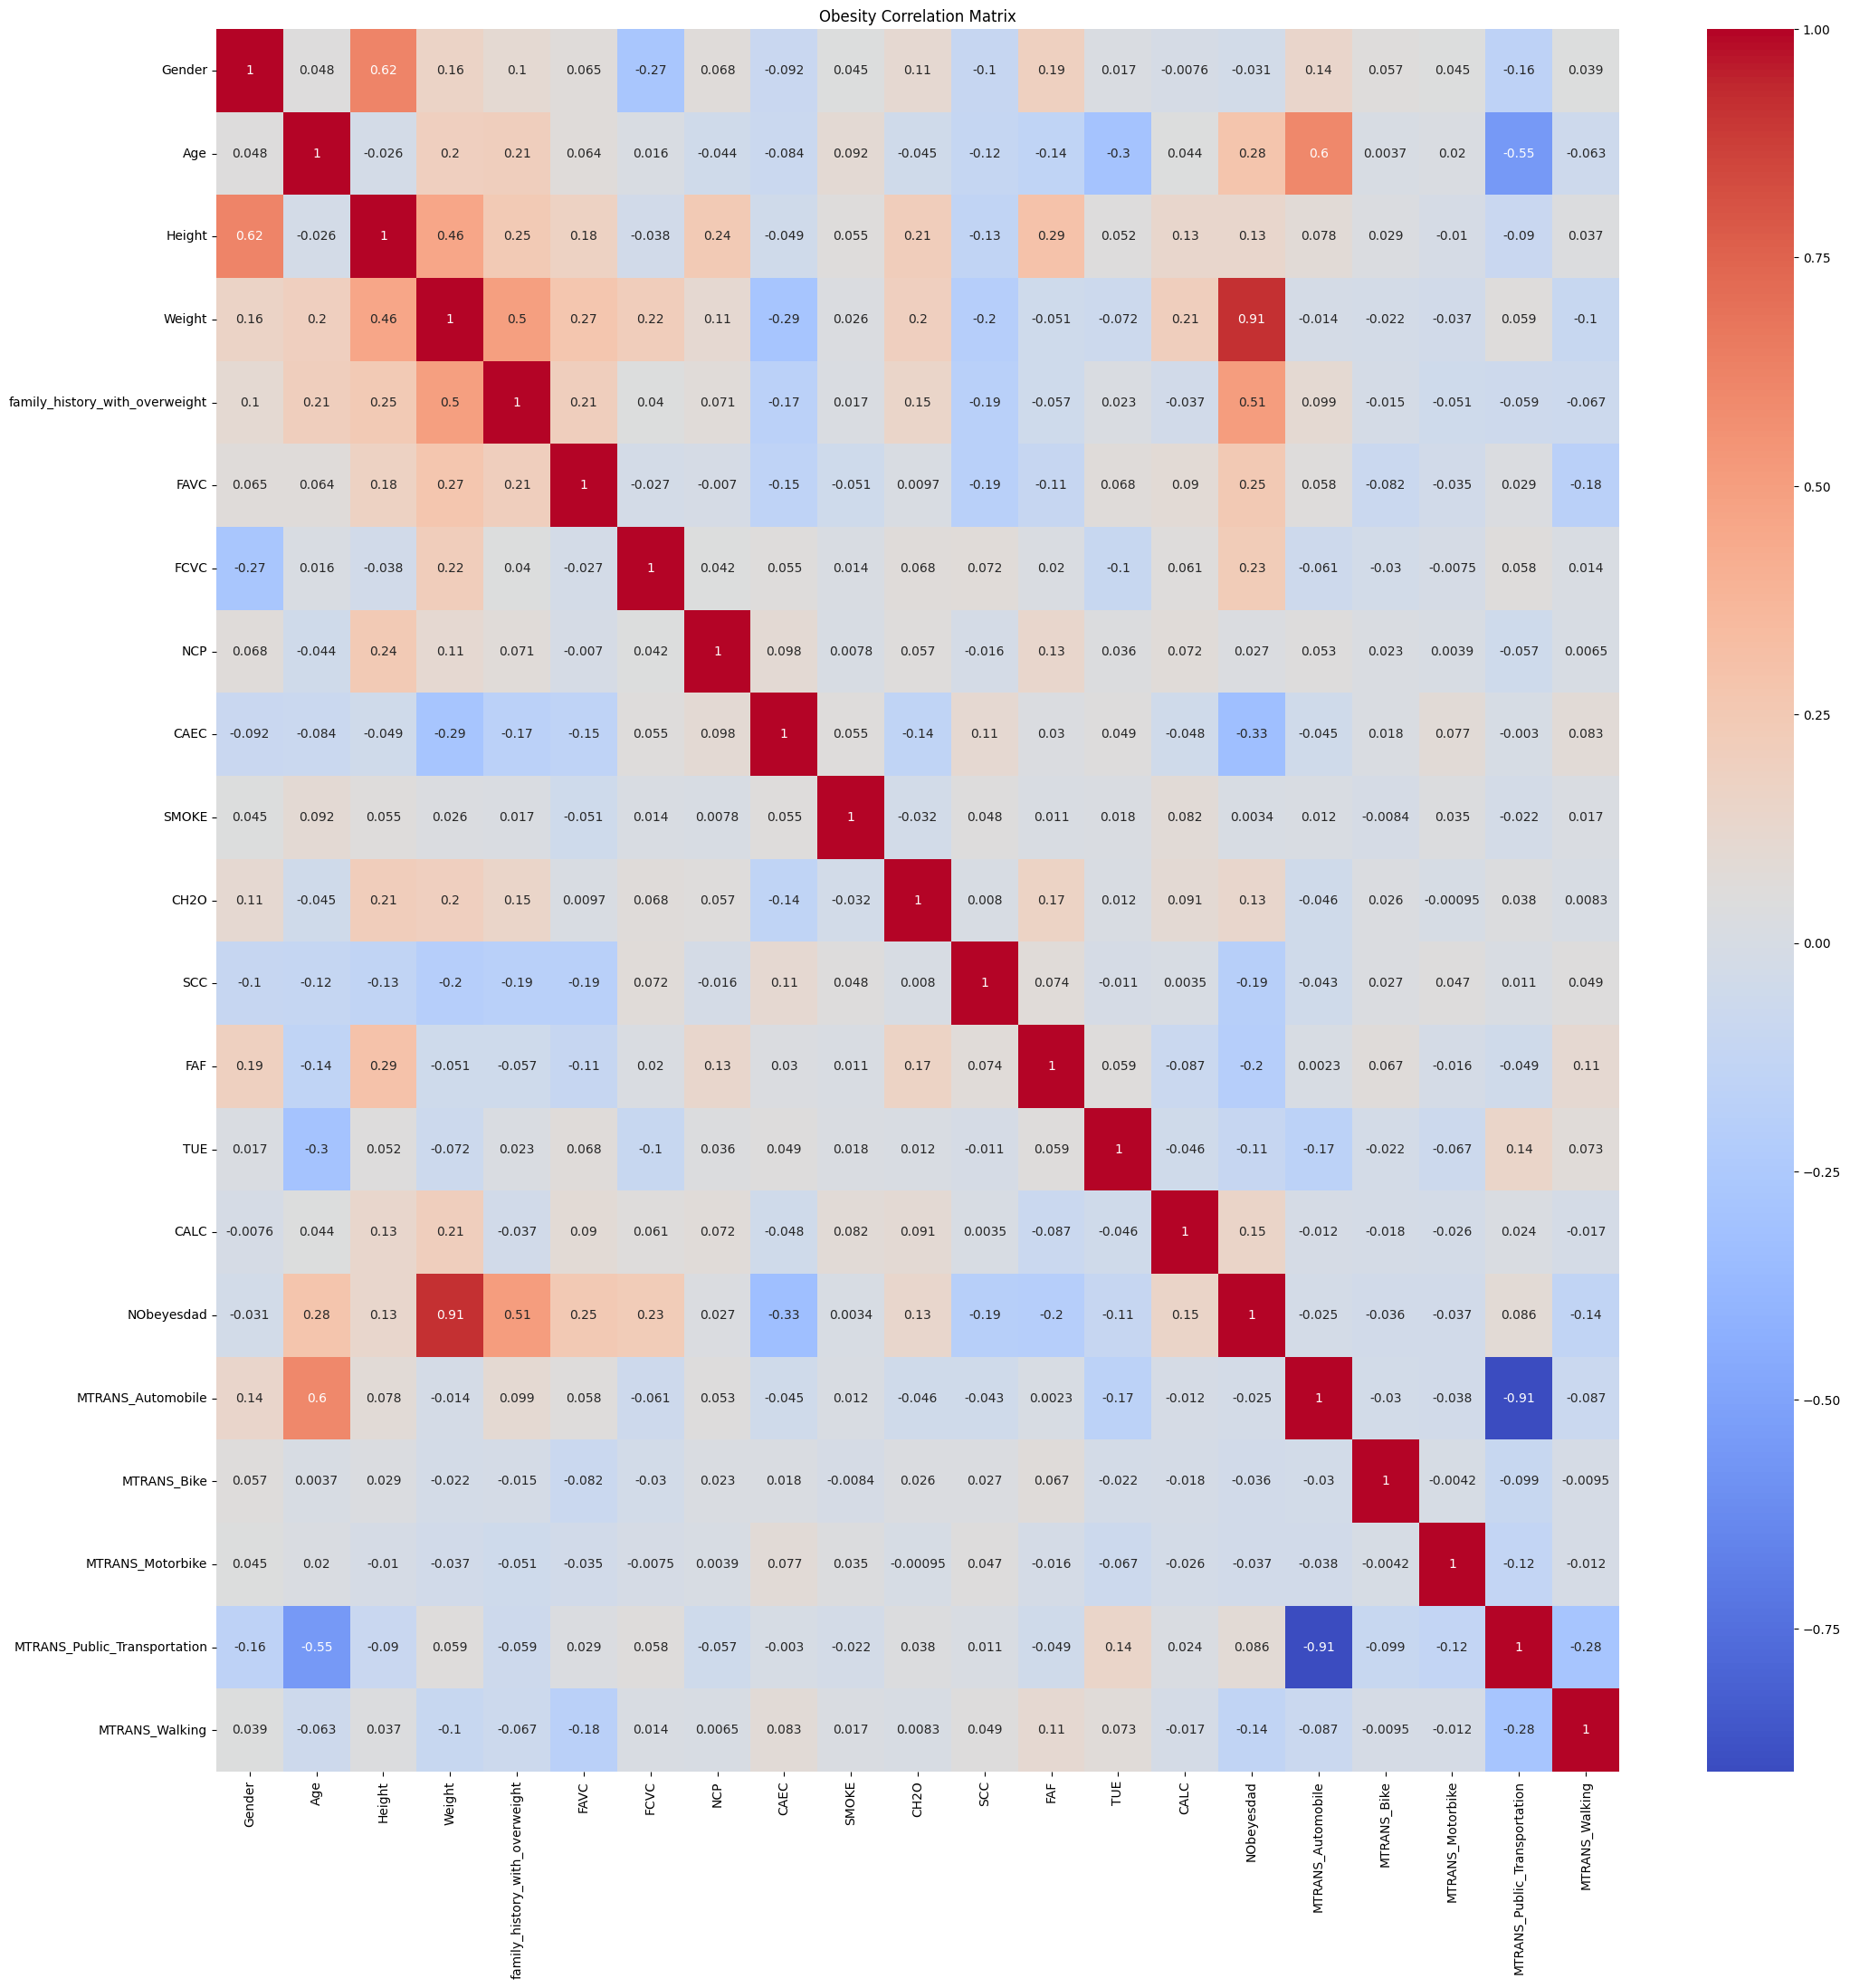

In [98]:
#Reference 4: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/

#Create the correlation matrix using the encoded and feature scaled data.
correlationMatrix = ObesityDataSetCsv.corr()

#The figure has to be large because there are 22 features
plt.figure(figsize=(25,25))
sns.heatmap(correlationMatrix, annot=True, cmap="coolwarm")
plt.title("Obesity Correlation Matrix")
plt.show()

As can be seen above, Weight is highly correlated with the NObeyesdad target. This is because Weight is one of the two features used to calculate NObeyesdad. Since the goal of this paper is to see if NObeyesdad can be predicted without the two features used to calcualte it, both weight and height will be dropped. I will also look into dropping MTRANS_Automobile because of its correlation with MTRANS_Public_Transportation. Dropping features will be performed during the train test split creation for the individual models. My criteria for dropping a feature was very high correlation at .9 or -.9.

Confusion Matrix Implementation. This will provide the True Positives, True Negatives, False Positives, and False Negatives. This will also provide the F1 score, recall, precision, and accuracy. Macro and weighted averages are also provided.

In [99]:
#Reference: https://www.geeksforgeeks.org/machine-learning/how-to-plot-confusion-matrix-with-labels-in-sklearn/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.multilabel_confusion_matrix.html

#Takes in the Ground truth and the predictions
def createConfusionMatrix(yData, predicData):

    #Creates the confusion matrix
    confusionMatrix = confusion_matrix(yData, predicData)

    #Provided so that I can remember exactly what each value represents.
    print("Multiclass Entries:\n 0: Insufficient_Weight\n 1: Normal_Weight\n 2: Overweight_Level_I\n 3: Overweight_Level_II\n 4: Obesity_Type_I\n 5: Obesity_Type_II\n 6: Obesity_Type_III")
    
    #Creates the multiclass confusion matrix since I have 7 values for my target
    prettyConfusionMatrix = ConfusionMatrixDisplay(confusionMatrix)

    #Set the color to coolwarm because my favorite color is red. Changed back to blue because coolwarm was absolutly ugly.
    prettyConfusionMatrix.plot(cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.show()
    
    #prints precision, recall, and F1
    print(classification_report(yData, predicData))

First I will try a simple model to see if I even need to put the work into developing a more complex model.

Implement the first model: Logistic Regression

Build the model to test if I can predict obesity without weight and height

Split the data into Train / Test for the Logistic Regression Model Excluding Weight and Height. I use the common 80%/20% training data / testing data split.

In [100]:
#Reference: https://www.geeksforgeeks.org/machine-learning/how-to-split-a-dataset-into-train-and-test-sets-using-python/
#Reference: https://www.geeksforgeeks.org/python/python-pandas-dataframe-astype/

#Features not included. Height, Weight, MTRANS_Automobile
logisticFeatures = ObesityDataSetCsv[["Gender", "Age", "family_history_with_overweight", "FAVC", "FCVC", "NCP", "CAEC", "SMOKE", "CH2O", "SCC", 
                              "FAF", "TUE", "CALC", "MTRANS_Bike", "MTRANS_Motorbike", "MTRANS_Public_Transportation", "MTRANS_Walking"]]
#Target Class
targetClass = ObesityDataSetCsv[["NObeyesdad"]]

#Gender, Family_history_with_overweight, FAVC, SMOKE, SCC are all registering as type object and need to be convereted for the models to run properly
logisticFeatures["Gender"] = logisticFeatures["Gender"].astype(int)
logisticFeatures["family_history_with_overweight"] = logisticFeatures["family_history_with_overweight"].astype(int)
logisticFeatures["FAVC"] = logisticFeatures["FAVC"].astype(int)
logisticFeatures["SMOKE"] = logisticFeatures["SMOKE"].astype(int)
logisticFeatures["SCC"] = logisticFeatures["SCC"].astype(int)

#The type needs set as an int. Even though there are only integers in the column, the column itself stayed labeled as an object
targetClass = targetClass.astype(int)

#Create the train test split for the logistic regression model
xTrainingData, xTestingData, yTrainingData, yTestingData = train_test_split(logisticFeatures, targetClass, test_size=0.2, shuffle=True)

Review the target dispersion

In [101]:
#Review details about the target data to check for class imbalance
print(yTrainingData.value_counts())
print(yTestingData.value_counts())

NObeyesdad
4             282
6             253
5             239
2             237
3             230
1             230
0             217
Name: count, dtype: int64
NObeyesdad
6             71
4             69
3             60
5             58
1             57
0             55
2             53
Name: count, dtype: int64


Fix warnings with the data so it works with the Logistic Regression model. I recieved warnings the first time I tried to run the model and had to implement the below code.

In [102]:
#Reference: https://stackoverflow.com/questions/48841624/dataframe-object-has-no-attribute-ravel-when-transforming-target-variable

#Logistic Regression warning: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
#Converts the data from a 2D dataframe to a 1D list
yTrainingData = yTrainingData.values.ravel()
yTestingData = yTestingData.values.ravel()

Build the simple logistic regression model

In [103]:
#Reference: https://www.geeksforgeeks.org/artificial-intelligence/multiclass-logistic-regression/

#Implement a simple model for logistic regression as a first test for the data
#The hard coded parameters are the default paramteres for this model
def SimpleLogisticRegressionModel(optimizer, iterations=100, regularizationType=0, regularizationValue=1, tal=0.0001):

    #Build the model
    #FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10
    #By default the model will use softmax as target is multiclass
    logisticRegressionModel = LogisticRegression(solver=optimizer, max_iter=iterations, l1_ratio=regularizationType, C=regularizationValue, tol=tal, verbose=True)

    #Train the model
    logisticRegressionModel.fit(xTrainingData, yTrainingData)

    #Recieve the predictions from the testing data
    predictions = logisticRegressionModel.predict(xTestingData)

    #Create a confusion matrix to view model metrics
    createConfusionMatrix(yTestingData, predictions)

    #Compute what percentage of the predictions were correct against the ground truth
    accuracy = accuracy_score(yTestingData, predictions)
    print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

    #Below checks for overfitting. If the model performs perfectly on the training data then then model has most likely overfitted to it.
    OverfitTestL = logisticRegressionModel.predict(xTrainingData)
    OverfitAccuracyL = accuracy_score(yTrainingData, OverfitTestL)
    #createConfusionMatrix(yTrainingData, OverfitTestL)
    print(f"Overfit Check, Accuracy: {OverfitAccuracyL:.4f}")

Call the model

Test with Default Parameters first. Used to get a baseline. The default solver for this model is lbfgs. 

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


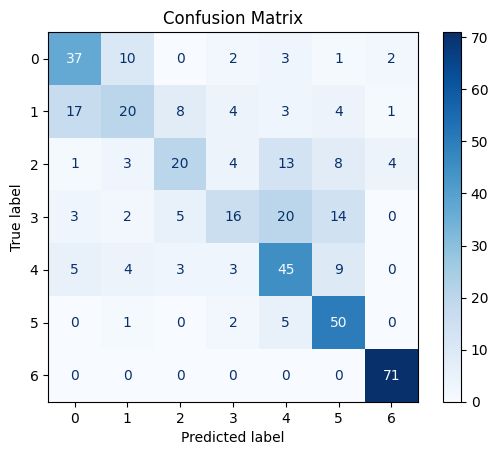

              precision    recall  f1-score   support

           0       0.59      0.67      0.63        55
           1       0.50      0.35      0.41        57
           2       0.56      0.38      0.45        53
           3       0.52      0.27      0.35        60
           4       0.51      0.65      0.57        69
           5       0.58      0.86      0.69        58
           6       0.91      1.00      0.95        71

    accuracy                           0.61       423
   macro avg       0.59      0.60      0.58       423
weighted avg       0.60      0.61      0.59       423

Logistic Regression Model Accuracy: 0.6123
Overfit Check, Accuracy: 0.5942


In [104]:
#lbfgs added just for a visual, if used with no parameters lbfgs would be used anyway
SimpleLogisticRegressionModel('lbfgs')
#ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT: iterations 100

Test with many other parameters to see if I can get a better output.

GridSearchCV is used to test parameters, it was the best way I was able to find to test a lot of parameters without bloating my code. GridSearchCV uses K fold cross validation where K is 5.

In [ ]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/

#solver: Algorithm used for optimization for the model
#max_iter: Number of epoch I let the model take. Even at 1000 it often never finishes. I didn't let this get too high because I wanted to prevent overfitting.
#l1_ratio: Regularization forumulas. Kept as Ridge because Lasso broken many of the solvers.
#tol: Stopping criteria.
#C: I believe this is regularization strength.

#Set parameters to test, the first entries are the defaults for the logistic regression model from scikit learn.
logsticParameters = {
    'solver': ['lbfgs', 'saga', 'sag', 'newton-cg', 'newton-cholesky'],
    'max_iter': [100, 500, 1000],
    'tol': [0.0001, 0.01],
    'C': [1.0, 0.5]
}

#'liblinear' solver does not support multiclass so it will not be used

#Set hard coded parameters for the model, these parameters are not ment to change.
#Many solvers don't support L1 Lasso regularization, thus Lasso was removed.
#Saga is actually the only solver that supports Lasso. I will test this separately.
gridSearchLogistic = LogisticRegression(l1_ratio=0)

#Error Score 0 allows the model to continue if one optimizer fails with the provided parameters
#This function tries all of the provided parameters with eachother and provides the parameters with the best accuracy.
#Since my classes are relatively similar in size, I am opting to use accuracy over other metrics.
#The GridSearchCV also struggled and had many issues/errors when trying to implement other metrics for comparison so I have stuck to accuracy.
#Uses cross validation, default cross validation is 5
logsticGridModel = GridSearchCV(gridSearchLogistic, logsticParameters, error_score=0)

#Parameter testing starts here
logsticGridModel.fit(xTrainingData, yTrainingData)

#Provides the best paramters and the accuracy score they got on the training data. The training data has to be used for testing the paramters.
print("Best Parameters:", logsticGridModel.best_params_)
print("Best Accuracy Score:", logsticGridModel.best_score_)

Best Parameters: {'C': 1.0, 'max_iter': 100, 'solver': 'saga', 'tol': 0.01}
Best Accuracy Score: 0.5793794883500432


Test the Logistic Regression Model using the "Best Parameters" from the previous cell. Ignore Convergence Warning, this will show up on combinations of parameters that did not converge.

Note, occasionally there were variations in the best paramters. This is because I am randomizing my train/test split and not using a seed.

convergence after 18 epochs took 0 seconds
Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


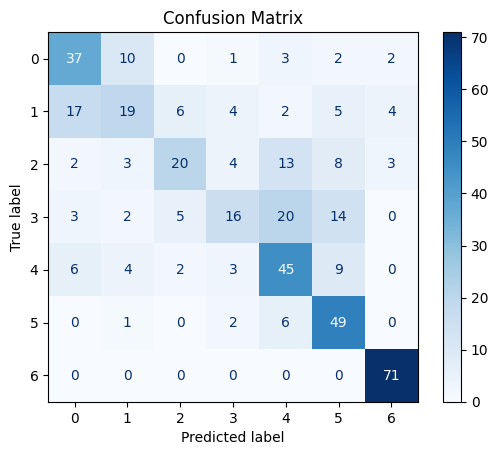

              precision    recall  f1-score   support

           0       0.57      0.67      0.62        55
           1       0.49      0.33      0.40        57
           2       0.61      0.38      0.47        53
           3       0.53      0.27      0.36        60
           4       0.51      0.65      0.57        69
           5       0.56      0.84      0.68        58
           6       0.89      1.00      0.94        71

    accuracy                           0.61       423
   macro avg       0.59      0.59      0.57       423
weighted avg       0.60      0.61      0.59       423

Logistic Regression Model Accuracy: 0.6076
Overfit Check, Accuracy: 0.5912


In [106]:
#These are the best parameters from the previous cell.
SimpleLogisticRegressionModel('sag', 1000, 0, 1, 0.01)

I have one final test. There is only 1 solver (saga) able to use Lasso Regularization. Including it in my GridSearchCV crashed the cell. Below I test the saga solver with Lasso Regularization using the best parameters found during the gridsearchcd for completion sake.

convergence after 22 epochs took 0 seconds
Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


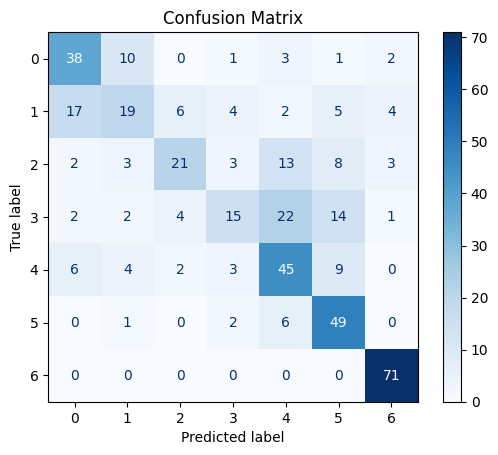

              precision    recall  f1-score   support

           0       0.58      0.69      0.63        55
           1       0.49      0.33      0.40        57
           2       0.64      0.40      0.49        53
           3       0.54      0.25      0.34        60
           4       0.49      0.65      0.56        69
           5       0.57      0.84      0.68        58
           6       0.88      1.00      0.93        71

    accuracy                           0.61       423
   macro avg       0.60      0.60      0.58       423
weighted avg       0.60      0.61      0.59       423

Logistic Regression Model Accuracy: 0.6099
Overfit Check, Accuracy: 0.5900


In [107]:
#Lasso Regularization saga using best output from the GridSearchCV
SimpleLogisticRegressionModel('saga',1000, 1, 1, 0.01)

I was able to achieve slightly improved metrics by using the saga solver with Lasso regularization and the best paramteres from the GridSearchCV cell.

Unfortunantly, metrics this low are only a little better then random guessing. At this point I have deduced that the simple logistic regression model can't predict obesity levels well without height and weight.

The below example is to show you that with only height and weight, the default logistic regression model performs extremely well. This is why I am so interested to find out if features outside of these two can produce high prediction results.

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


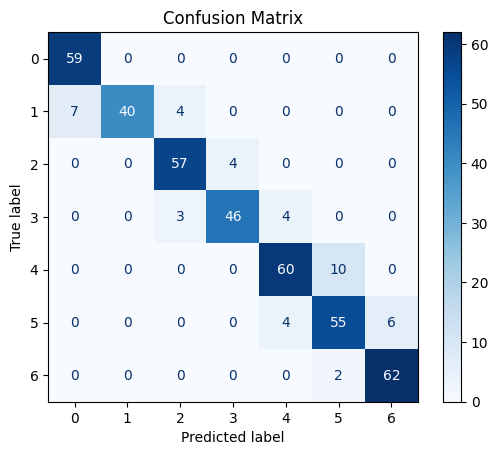

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        59
           1       1.00      0.78      0.88        51
           2       0.89      0.93      0.91        61
           3       0.92      0.87      0.89        53
           4       0.88      0.86      0.87        70
           5       0.82      0.85      0.83        65
           6       0.91      0.97      0.94        64

    accuracy                           0.90       423
   macro avg       0.90      0.89      0.90       423
weighted avg       0.90      0.90      0.90       423



In [108]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

#Height / Weight Example
#Make the train / test split
logisticFeaturesTest = ObesityDataSetCsv[["Height", "Weight"]]
targetClassTest = ObesityDataSetCsv[["NObeyesdad"]]
targetClassTest = targetClassTest.astype(int)
xTrainingDataTest, xTestingDataTest, yTrainingDataTest, yTestingDataTest = train_test_split(logisticFeaturesTest, targetClassTest, test_size=0.2, shuffle=True)
yTrainingDataTest = yTrainingDataTest.values.ravel()
yTestingDataTest = yTestingDataTest.values.ravel()

#Make the default model
logisticRegressionModelTest = LogisticRegression(verbose=True)
logisticRegressionModelTest.fit(xTrainingDataTest, yTrainingDataTest)
predictionsTest = logisticRegressionModelTest.predict(xTestingDataTest)

#Show the extremely good metrics
createConfusionMatrix(yTestingDataTest, predictionsTest)

Find a Better / More Complex Model

I have decided to use the Multi Layer Perceptron Neural Network (MLP). This model is more robust and has many more parameters that I can adjust to achieve better metrics. In a way it is like a bunch of logistic regression models. This model will also use softmax just like the logistic regression model for the output layer.

Build the Loss Plot. This lets me view the gradients being reduced and model stabalization.

In [109]:
#Reference: https://stackoverflow.com/questions/48123023/how-to-appropriately-plot-the-losses-values-acquired-by-loss-curve-from-mlpcl

#The MLP classifier model stores the loss history by default. Takes in the history of loss values.
def plotLossFunction(lossData):
    plt.figure(figsize=(5, 5))
    #Plots the data as a curve
    plt.plot(lossData)
    plt.title('Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

ROC Curve. Implemented to review how well my model does at different thresholds.

In [110]:
#Reference: https://www.geeksforgeeks.org/machine-learning/how-to-plot-roc-curve-in-python/
#Reference: https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.auc.html

#A funtion that computes and prints the roc curve for multi class data
def createRocCurve(groundTruth, probabilities):

    #Label binarize esentially does one hot encoding on the ground truth Y data
    hotYData = label_binarize(groundTruth, classes=[0, 1, 2, 3, 4, 5, 6])

    #False Positive Rate
    fpr = dict()
    #True Positive Rate
    tpr = dict()
    #Area Under the Curve Score
    rocAuc = dict()
    #The label for each of the ROC Curve Lines
    labels = ['Underweight', 'Normal', 'Overweight', 'Overweight II', 'Obesity I', 'Obesity II', 'Obesity III']

    #Sets the size of the figure. Needs set here so all plots end up in the same figure otherwise the random chance line kept ending up by itself.
    plt.figure(figsize=(7,7))

    #This loops through each of the 7 classes
    for i in range(7):
        #Uses roc_curve to get the fpr and trp. The hotYData and probabilities are matrix's and the i is pulling that column of the data.
        #thresholds is not used but the roc_curve function returns it and it has to be captured somewhere
        fpr[i], tpr[i], thresholds = roc_curve(hotYData[:, i], probabilities[:, i])

        #The auc function computes the area under the curve value from the fpr and tpr
        rocAuc[i] = auc(fpr[i], tpr[i])

        #Plots each ROC curve line and their scores
        plt.plot(fpr[i], tpr[i], label=f'{labels[i]} AUC Score = {rocAuc[i]:.4f}')

    #Plots the random chance line
    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance 50%')

    #Standard plt x label, y label and title
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multiclass ROC Curve - One vs Rest')
    plt.legend()
    plt.show()

Train / Test split for Multi Layer Perceptron Neural Network. Uses the normal 80% / 20% Training data Testing data split.

In [111]:
#Reference: https://www.geeksforgeeks.org/machine-learning/how-to-split-a-dataset-into-train-and-test-sets-using-python/
#Reference: https://www.geeksforgeeks.org/python/python-pandas-dataframe-astype/
#Reference: https://stackoverflow.com/questions/48841624/dataframe-object-has-no-attribute-ravel-when-transforming-target-variable
#Training data encoding/normalizing was perforemd earlier and will not be done again. I will be using that same dataframe. The class has not been converted to int this time and needs done again.

#Features dropped weight, height, MTRANS_Automobile
MLPFeatures = ObesityDataSetCsv[["Gender", "Age", "family_history_with_overweight", "FAVC", "FCVC", "NCP", "CAEC", "SMOKE", "CH2O", "SCC", 
                              "FAF", "TUE", "CALC", "MTRANS_Bike", "MTRANS_Motorbike", "MTRANS_Public_Transportation", "MTRANS_Walking"]]
#Target Classes
MLPClass = ObesityDataSetCsv[["NObeyesdad"]]

#print(features.dtypes) Gender, Family_history_with_overweight, FAVC, SMOKE, SCC are all registering as type object and need to be convereted for the models to run properly
MLPFeatures["Gender"] = MLPFeatures["Gender"].astype(int)
MLPFeatures["family_history_with_overweight"] = MLPFeatures["family_history_with_overweight"].astype(int)
MLPFeatures["FAVC"] = MLPFeatures["FAVC"].astype(int)
MLPFeatures["SMOKE"] = MLPFeatures["SMOKE"].astype(int)
MLPFeatures["SCC"] = MLPFeatures["SCC"].astype(int)

#The type needs set as an int. Even though there are only integers in the column, the column itself stayed labeled as an object
MLPClass = MLPClass.astype(int)

#Create the train test split for the dataset 80 / 20 split.
xMLPTrainingData, xMLPTestingData, yMLPTrainingData, yMLPTestingData = train_test_split(MLPFeatures, MLPClass, test_size=0.2, shuffle=True)

#Converts the data from a 2D dataframe to a 1D list
yMLPTrainingData = yMLPTrainingData.values.ravel()
yMLPTestingData = yMLPTestingData.values.ravel()

Build the MLP model. scikit learn MLPClassifier is being used.

In [112]:
#Reference: https://www.geeksforgeeks.org/machine-learning/classification-using-sklearn-multi-layer-perceptron/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#The Shuffle parameter defaults to true for optimizers that use it
#The Random state parameter should be set to none by default meaning there is randomization every time

#Below the default options for MLPClassifier have been hard coded. Other parameters exist but they are not ones you would commonly adjust.
def MultiLayerPNN(optimizer='adam', a=0.0001, hidden=(100,), active='relu', lr=0.001, iterations=200, bSize='auto', eStop=False):
    
    #Create the model
    MLPNeuralNetwork = MLPClassifier(solver=optimizer, alpha=a, hidden_layer_sizes=hidden, activation=active, learning_rate_init=lr, max_iter=iterations, batch_size=bSize, early_stopping=eStop, verbose=True)
    
    #Train the model
    MLPNeuralNetwork.fit(xMLPTrainingData, yMLPTrainingData)

    #Test the trained model against the testing data to obtain predictions
    MLPPredictions = MLPNeuralNetwork.predict(xMLPTestingData)

    #Get the accuracy score from the testing data ground truth and the above predictions
    MLPAccuracy = accuracy_score(yMLPTestingData, MLPPredictions)

    #The lbfgs solver does not have the loss_curve_ attribute and breaks when ran. Provide a loss curve only when lbfgs is not used.
    if optimizer != 'lbfgs':
        plotLossFunction(MLPNeuralNetwork.loss_curve_)
    else:
        print("lbfgs solver used, no loss_curve_ attribute to plot")

    #Creates the Roc Curve for all classes
    rocCurvePredict = MLPNeuralNetwork.predict_proba(xMLPTestingData)
    createRocCurve(yMLPTestingData, rocCurvePredict)

    #Provide a confusion matrix to obtain metrics
    createConfusionMatrix(yMLPTestingData, MLPPredictions)
    
    #Print the accuracy score
    print(MLPAccuracy)

    #I realized after I had done a large amount of testing that my models were actually overfitting. This is done to track overfitting and attempt to resolve the issue. Also added to the Logistic Regression Model.
    #Tests accuracy for overfitting.
    OverfitTest = MLPNeuralNetwork.predict(xMLPTrainingData)
    OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
    print("Overfit test, Accuracy:", OverfitAccuracy)
    #createConfusionMatrix(yMLPTrainingData, OverfitTest)

Call the MLPClassifier model using the default parameters. The adam solver is the MLPClassifier models default solver.

Default Model (uses adam solver)

Iteration 1, loss = 1.91906788
Iteration 2, loss = 1.80980985
Iteration 3, loss = 1.71794402
Iteration 4, loss = 1.63578319
Iteration 5, loss = 1.56348395
Iteration 6, loss = 1.49711534
Iteration 7, loss = 1.43858261
Iteration 8, loss = 1.38748270
Iteration 9, loss = 1.34133237
Iteration 10, loss = 1.30085464
Iteration 11, loss = 1.26514291
Iteration 12, loss = 1.23214456
Iteration 13, loss = 1.20276913
Iteration 14, loss = 1.17625473
Iteration 15, loss = 1.15275024
Iteration 16, loss = 1.13037585
Iteration 17, loss = 1.10895014
Iteration 18, loss = 1.08919603
Iteration 19, loss = 1.07122089
Iteration 20, loss = 1.05295270
Iteration 21, loss = 1.03651085
Iteration 22, loss = 1.02069751
Iteration 23, loss = 1.00529954
Iteration 24, loss = 0.99090499
Iteration 25, loss = 0.97653289
Iteration 26, loss = 0.96361211
Iteration 27, loss = 0.94977492
Iteration 28, loss = 0.93893356
Iteration 29, loss = 0.92561891
Iteration 30, loss = 0.91563441
Iteration 31, loss = 0.90377266
Iteration 32, los

\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


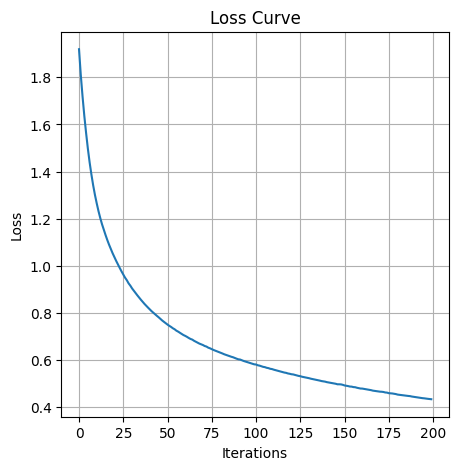

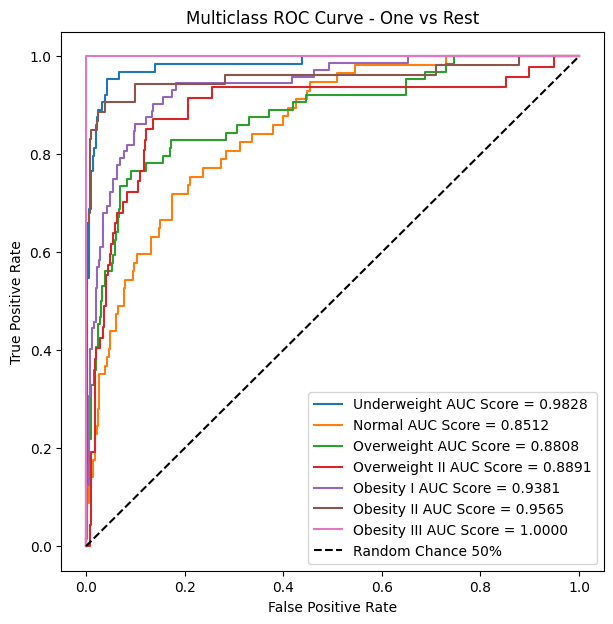

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


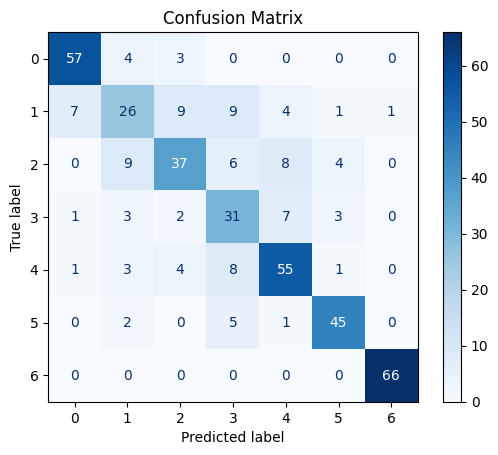

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        64
           1       0.55      0.46      0.50        57
           2       0.67      0.58      0.62        64
           3       0.53      0.66      0.58        47
           4       0.73      0.76      0.75        72
           5       0.83      0.85      0.84        53
           6       0.99      1.00      0.99        66

    accuracy                           0.75       423
   macro avg       0.74      0.74      0.74       423
weighted avg       0.75      0.75      0.75       423

0.7494089834515366
Overfit test, Accuracy: 0.8643364928909952


In [113]:
#For this model everything except for the verbose option has been left default for the MLPClassifier. Adam only included for visual.
MultiLayerPNN('adam')

These metrics are much better than the Logistic Regression model. Unfortunantly, I believe at this point there are signs of overfitting in the model as seen by reviewing the accuracy for both the training and testing data. The ROC curve shows that the model should perform well depending on the threshold. Unfortunantly it looks like the built in threshold adjuster from scikit learn is for binary classes only. I will addressing the overfitting issue and manipulate the parameters.

Resolve the overfitting issue, set early_stop = True. This prevents the model from memorizing the training data because this is a relatively small dataset. Early stop holds back a 10% validation data set and stops the fitting when the validation score does not improve more than the tol value (default 0.0001) for 10 iterations.

Iteration 1, loss = 2.03644427
Validation score: 0.195266
Iteration 2, loss = 1.92553135
Validation score: 0.260355
Iteration 3, loss = 1.83255929
Validation score: 0.325444
Iteration 4, loss = 1.75314243
Validation score: 0.372781
Iteration 5, loss = 1.68231135
Validation score: 0.449704
Iteration 6, loss = 1.61695209
Validation score: 0.497041
Iteration 7, loss = 1.55781045
Validation score: 0.520710
Iteration 8, loss = 1.50407142
Validation score: 0.532544
Iteration 9, loss = 1.45514909
Validation score: 0.544379
Iteration 10, loss = 1.41090270
Validation score: 0.556213
Iteration 11, loss = 1.37104916
Validation score: 0.568047
Iteration 12, loss = 1.33526839
Validation score: 0.568047
Iteration 13, loss = 1.30232699
Validation score: 0.573964
Iteration 14, loss = 1.27236614
Validation score: 0.579882
Iteration 15, loss = 1.24477654
Validation score: 0.591716
Iteration 16, loss = 1.22065223
Validation score: 0.591716
Iteration 17, loss = 1.19709437
Validation score: 0.597633
Iterat

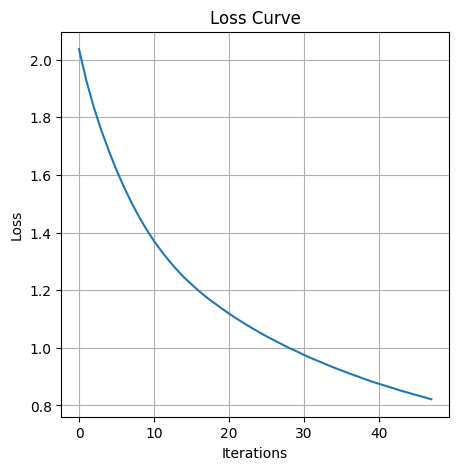

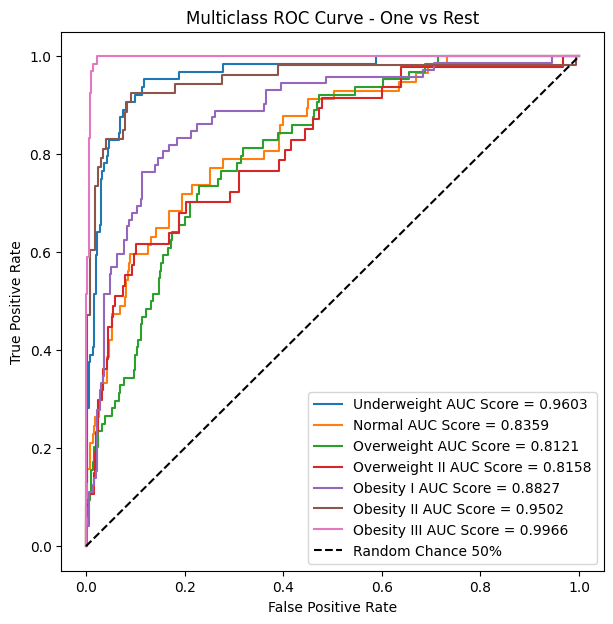

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


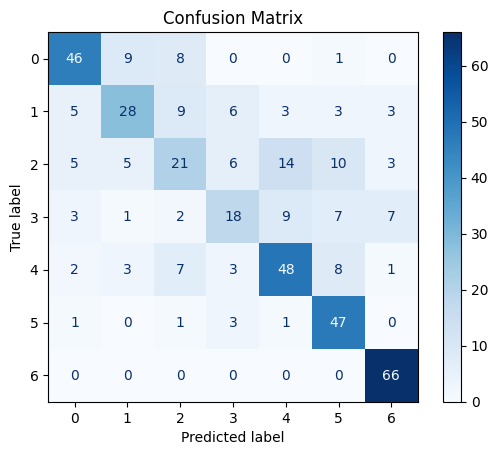

              precision    recall  f1-score   support

           0       0.74      0.72      0.73        64
           1       0.61      0.49      0.54        57
           2       0.44      0.33      0.38        64
           3       0.50      0.38      0.43        47
           4       0.64      0.67      0.65        72
           5       0.62      0.89      0.73        53
           6       0.82      1.00      0.90        66

    accuracy                           0.65       423
   macro avg       0.62      0.64      0.62       423
weighted avg       0.63      0.65      0.63       423

0.6477541371158393
Overfit test, Accuracy: 0.6943127962085308


In [114]:
#Set early stopping to prevent overfitting. All other parameters are still default.
MultiLayerPNN('adam', eStop=True)
#The validation score output is provided by the eStop parameter

I believe adding the early stop has improved the overfitting issue but not completly resovled it. Unfortunantly it has caused the metrics to considerably decline. I will continue trying to resolve the overfitting issue as well as increasing model metrics by adjusting model parameters.

Since the MLPClassifier model is so complex, I will be testing the solvers independently as many of the paramters that work for one solver don't work for the others and cause the model to error.

The next two cells will get baselines for the SGD and LBFGS solvers, then I will use gridsearchcv to check other parameters.

Iteration 1, loss = 1.93189427
Validation score: 0.218935
Iteration 2, loss = 1.92082407
Validation score: 0.213018
Iteration 3, loss = 1.90613447
Validation score: 0.218935
Iteration 4, loss = 1.88989856
Validation score: 0.236686
Iteration 5, loss = 1.87415264
Validation score: 0.242604
Iteration 6, loss = 1.85880171
Validation score: 0.272189
Iteration 7, loss = 1.84383019
Validation score: 0.295858
Iteration 8, loss = 1.82939120
Validation score: 0.295858
Iteration 9, loss = 1.81560218
Validation score: 0.295858
Iteration 10, loss = 1.80224498
Validation score: 0.295858
Iteration 11, loss = 1.78944067
Validation score: 0.319527
Iteration 12, loss = 1.77680920
Validation score: 0.325444
Iteration 13, loss = 1.76478451
Validation score: 0.331361
Iteration 14, loss = 1.75291748
Validation score: 0.337278
Iteration 15, loss = 1.74127796
Validation score: 0.349112
Iteration 16, loss = 1.73033132
Validation score: 0.355030
Iteration 17, loss = 1.71945627
Validation score: 0.349112
Iterat

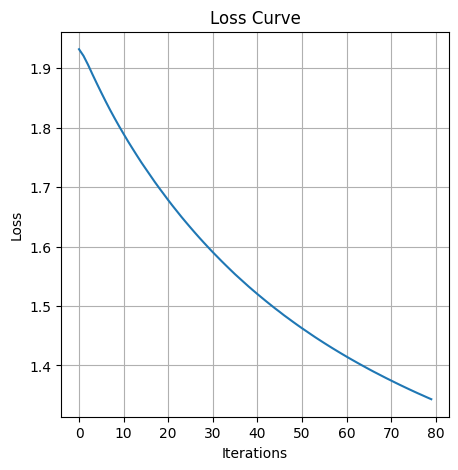

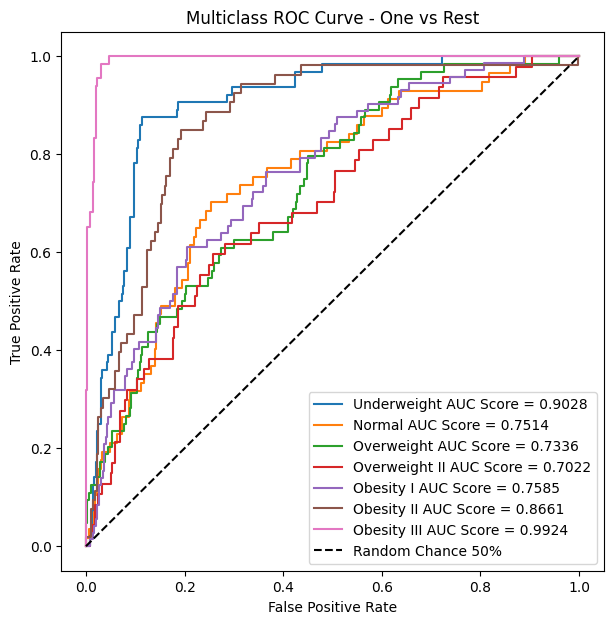

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


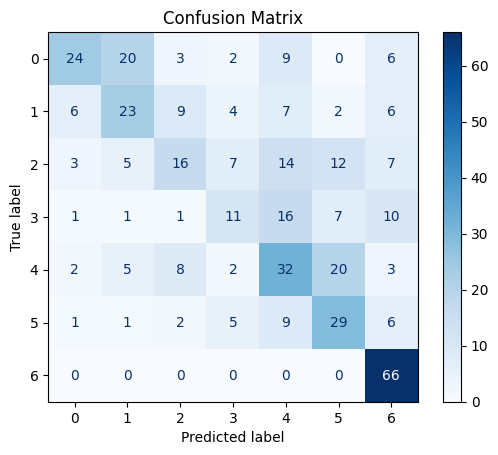

              precision    recall  f1-score   support

           0       0.65      0.38      0.48        64
           1       0.42      0.40      0.41        57
           2       0.41      0.25      0.31        64
           3       0.35      0.23      0.28        47
           4       0.37      0.44      0.40        72
           5       0.41      0.55      0.47        53
           6       0.63      1.00      0.78        66

    accuracy                           0.48       423
   macro avg       0.46      0.46      0.45       423
weighted avg       0.47      0.48      0.45       423

0.475177304964539
Overfit test, Accuracy: 0.533175355450237


In [115]:
#sgd baseline
#Stochastic Gradient Descent
MultiLayerPNN('sgd', eStop=True)

The SGD Metrics are very poor

lbfgs solver used, no loss_curve_ attribute to plot


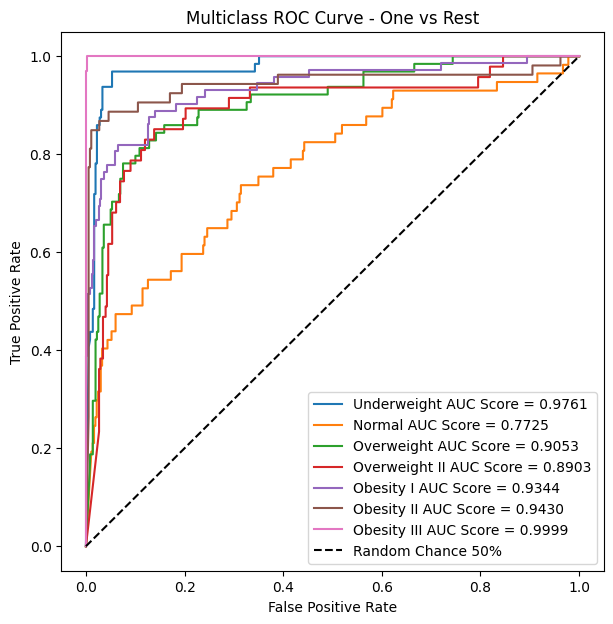

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


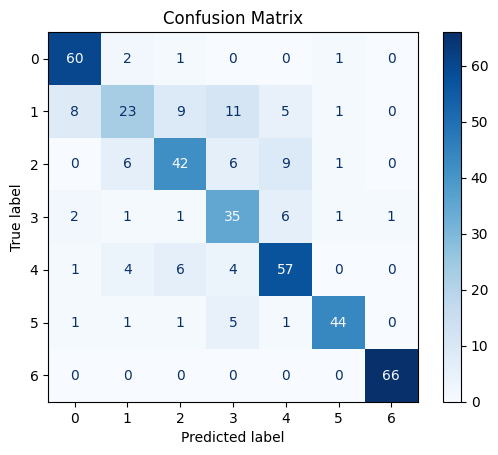

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        64
           1       0.62      0.40      0.49        57
           2       0.70      0.66      0.68        64
           3       0.57      0.74      0.65        47
           4       0.73      0.79      0.76        72
           5       0.92      0.83      0.87        53
           6       0.99      1.00      0.99        66

    accuracy                           0.77       423
   macro avg       0.77      0.77      0.76       423
weighted avg       0.77      0.77      0.77       423

0.7730496453900709
Overfit test, Accuracy: 1.0


In [116]:
#lbfgs baseline
#lbfgs can't use early stop and thus it has not been set
#Limited memory broyden fletcher goldfarb shanno
#lbfgs does not have the loss data that the other solvers do so no loss curve will be produced
#Sometimes a warning shows up to increase the number of iterations, ignore this for now it is tested later
MultiLayerPNN('lbfgs')

As you can see by the perfect training data accuracy, the lbfgs model has overfitted.

I use GridSearchCV to find the best parameters for each solver. I do this for each solver because many of the parameters that work for one solver don't work for others. When having all solvers in the same GridSearchCV I was getting many errors. Prior to using GridSearchCV I was running each seperate parameter line individually and had over 100 lines of different parameters. This became too hard to manage and thus I changed to using GridSearchCV

The below 3 GridSearchCV Cells parameters are difinitive. These are the best parameters through testing and will not be questioned unless I run into errors with the models or vast overfitting.

Adam Solver GridSearchCV

In [117]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#These are all of the possible parameters for the Adam solver. The values below are the default parameters.
#The commented parameters below are just examples of what can be changed. Originally I had a vast number of parameters that caused my GridSearchCV to take days to finish.
#The 3 solvers I tested took over 3 days to finish running so I had to reduce the parameters. You can see an example of this in the report.
# parameters = {
#     'hidden_layer_sizes': [(100,)],
#     'activation': ['relu'],
#     'solver': ['adam'],
#     'alpha': [0.0001],
#     'batch_size': ['auto'],
#     'learning_rate_init': [0.001],
#     'max_iter': [200],
#     'shuffle': [True],
#     'random_state': [None],
#     'tol': [0.0001],
#     'verbose': [True],
#     'warm_start': [False],
#     'early_stopping': [True],
#     'validation_fraction': [.1],
#     'beta_1': [0.9],
#     'beta_2': [0.999],
#     'epsilon': [0.00000001],
#     'n_iter_no_change': [10]
# }

#Set parameters to test
#Parameters have been reduced because of excessive computation times.
adamParameters = {
    'hidden_layer_sizes': [(100,), (18,), (256,), (18, 18), (128, 64), (128, 128), (16, 12, 8), (256, 128, 64)],
    'activation': ['relu', 'logistic', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.01, 0.1],
    'batch_size': ['auto', 32, 512],
    'tol': [0.0001, 0.1],
    'learning_rate_init': [0.001, 0.1],
    'n_iter_no_change': [10, 50]
}

#Set hard coded parameters for the mode, these parameters are not ment to change. Early stop should help the overfitting issues so I have increased the epoch.
gridSearchAdam = MLPClassifier(max_iter=1000, early_stopping=True)

#Default cross validation is 5
#The default scoring metric from MLPClassifier is used, this metric is Accuracy which should be acceptable as the classes are all similar sizes
#The n_jobs parameter tells the model to use more CPU core. This was an attempt to get the model to finish in an appropriate amount of time.
adamGridModel = GridSearchCV(gridSearchAdam, adamParameters, n_jobs=-4, verbose=True)

#Parameter testing starts here
adamGridModel.fit(xMLPTrainingData, yMLPTrainingData)

#A list of best parameters and the accuracy score they provided is printed by the below lines
print("Best Parameters:", adamGridModel.best_params_)
print("Best Accuracy Score:", adamGridModel.best_score_)

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits
Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001, 'n_iter_no_change': 50, 'solver': 'adam', 'tol': 0.0001}
Best Accuracy Score: 0.7873141011009077


sgd Solver (Stochastic gradient Descent) GridSearchCV

In [118]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#These are all of the possible parameters for the Adam solver. The values below are the default parameters.
#The commented parameters below are just examples of what can be changed. Originally I had a vast number of parameters that caused my GridSearchCV to take days to finish.
#The 3 solvers I tested took over 3 days to finish running so I had to reduce the parameters. You can see an example of this in the report.
# parameters = {
#     'hidden_layer_sizes': [(100,)],
#     'activation': ['relu'],
#     'solver': ['sgd'],
#     'alpha': [0.0001],
#     'batch_size': ['auto'],
#     'learning_rate': ['constant'],
#     'power_t': [0.5],
#     'learning_rate_init': [0.001],
#     'max_iter': [200],
#     'shuffle': [True],
#     'random_state': [None],
#     'tol': [0.0001],
#     'verbose': [True],
#     'warm_start': [False],
#     'momentum': [0.9],
#     'nesterovs_momentum': [True],
#     'early_stopping': [True],
#     'validation_fraction': [.1],
#     'n_iter_no_change': [10],
# }

#Set parameters to test
#Parameters have been reduced because of excessive computation times.
SGDparameters = {
    'hidden_layer_sizes': [(100,), (18,), (256,), (18, 18), (128, 64), (128, 128), (16, 12, 8), (256, 128, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate': ['constant', 'logistic', 'adaptive'],
    'solver': ['sgd'],
    'alpha': [0.0001, 0.1],
    'tol': [0.0001, 0.1],
    'batch_size': ['auto', 32, 512],
    'learning_rate_init': [0.001, 0.1],
    'n_iter_no_change': [10, 50]
}

#Set hard coded parameters for the mode, these parameters are not ment to change. Early stop should help the overfitting issues so I have increased the epoch.
SGDgridSearchMLPNN = MLPClassifier(max_iter=1000, early_stopping=True)

#Default cross validation is 5
#The default scoring metric from MLPClassifier is used, this metric is Accuracy which should be acceptable as the classes are all similar sizes
#The n_jobs parameter tells the model to use more CPU core. This was an attempt to get the model to finish in an appropriate amount of time.
SGDgridModel = GridSearchCV(SGDgridSearchMLPNN, SGDparameters, n_jobs=-4, verbose=True)

#Parameter testing starts here
SGDgridModel.fit(xMLPTrainingData, yMLPTrainingData)

#A list of best parameters and the accuracy score they provided is printed by the below lines
print("Best Parameters:", SGDgridModel.best_params_)
print("Best Accuracy Score:", SGDgridModel.best_score_)

Fitting 5 folds for each of 2304 candidates, totalling 11520 fits


.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3840 fits failed out of a total of 11520.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
602 fits failed with the following error:
Traceback (most recent call last):
  File ".venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File ".venv\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File ".venv\Lib\site-packages\sklearn\base.py", line 492, in _validate_params
    validate_parameter_constraints(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
  

Best Parameters: {'activation': 'relu', 'alpha': 0.1, 'batch_size': 32, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate': 'adaptive', 'learning_rate_init': 0.1, 'n_iter_no_change': 50, 'solver': 'sgd', 'tol': 0.1}
Best Accuracy Score: 0.7967973592260285


LBFGS Solver, limited memory broyden, fletcher, goldfarb, shannon: GridSearchCV

In [119]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#These are all of the possible parameters for the Adam solver. The values below are the default parameters.
#The commented parameters below are just examples of what can be changed. Originally I had a vast number of parameters that caused my GridSearchCV to take days to finish.
#The 3 solvers I tested took over 3 days to finish running so I had to reduce the parameters. You can see an example of this in the report.
#There are many less parameters available for this model than the Adam or SGD model.
# parameters = {
#     'hidden_layer_sizes': [(100,)],
#     'activation': ['relu'],
#     'solver': ['lbfgs'],
#     'alpha': [0.0001],
#     'batch_size': ['auto'],
#     'max_iter': [200],
#     'random_state': [None],
#     'tol': [0.0001],
#     'verbose': [True],
#     'warm_start': [False],
#     'validation_fraction': [.1],
#     'max_fun': [15000]
# }

#Set parameters to test
LBFGSparameters = {
    'hidden_layer_sizes': [(100,), (18,), (256,), (18, 18), (128, 64), (128, 128), (16, 12, 8), (256, 128, 64)],
    'activation': ['relu', 'logistic', 'tanh'],
    'solver': ['lbfgs'],
    'tol': [0.0001, 0.1],
    'alpha': [0.0001, 0.01, 0.1],
    'max_fun': [15000, 150000],
}

#Set hard coded parameters for the mode, these parameters are not ment to change. Early stop should help the overfitting issues so I have increased the epoch.
#Max fun was tested because the epoch were increased. This increases the number of loss function calls.
LBFGSgridSearchMLPNN = MLPClassifier(max_iter=1000)

#Default cross validation is 5
#The default scoring metric from MLPClassifier is used, this metric is Accuracy which should be acceptable as the classes are all similar sizes.
#The n_jobs parameter tells the model to use more CPU core. This was an attempt to get the model to finish in an appropriate amount of time.
LBFGSgridModel = GridSearchCV(LBFGSgridSearchMLPNN, LBFGSparameters, n_jobs=-4, verbose=True)

#Parameter testing starts here
LBFGSgridModel.fit(xMLPTrainingData, yMLPTrainingData)

#A list of best parameters and the accuracy score they provided is printed by the below lines
print("Best Parameters:", LBFGSgridModel.best_params_)
print("Best Accuracy Score:", LBFGSgridModel.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (128, 128), 'max_fun': 15000, 'solver': 'lbfgs', 'tol': 0.0001}
Best Accuracy Score: 0.7961880849121206


The best model metrics that I was able to get was for the lbfgs solver as seen through the accuracy outputs. Below I will use the testing data with the best parameters and review the results.

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


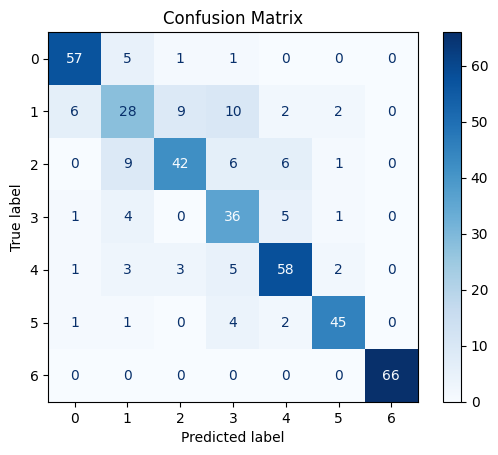

              precision    recall  f1-score   support

           0       0.86      0.89      0.88        64
           1       0.56      0.49      0.52        57
           2       0.76      0.66      0.71        64
           3       0.58      0.77      0.66        47
           4       0.79      0.81      0.80        72
           5       0.88      0.85      0.87        53
           6       1.00      1.00      1.00        66

    accuracy                           0.78       423
   macro avg       0.78      0.78      0.78       423
weighted avg       0.79      0.78      0.78       423

0.7848699763593381
Overfit test, Accuracy: 1.0


In [120]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#Best model parameters {'activation': 'relu', 'alpha': 0.1, 'hidden_layer_sizes': (128, 128), 'solver': 'lbfgs', 'tol': 0.0001, 'max_fun: 150000}

bestModel = MLPClassifier(
            solver='lbfgs', 
            alpha=0.1, 
            hidden_layer_sizes=(128, 128), 
            activation='relu', 
            max_iter=1000, 
            max_fun=150000,
            tol=0.0001,
            verbose=True)

#Fit the model to the training data
bestModel.fit(xMLPTrainingData, yMLPTrainingData)

#Predict the testing data
bestPredictions = bestModel.predict(xMLPTestingData)

#Compute the accuracy score
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

#Output for all other metrics
createConfusionMatrix(yMLPTestingData, bestPredictions)

#lbfgs does not have a loss curve attribute to print

print(bestAccuracy)

#Overfitting test
OverfitTest = bestModel.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)
#createConfusionMatrix(yMLPTrainingData, OverfitTest)

Clear Overfitting with the best model as seen by the 100% in every metric. This model is unacceptable.

Since the lbfgs model massively overfitted to the training data I will test the other solvers, adam and sgd to see if they experience the same overfitting problems.

Best Adam Solver Model using the parameters from the GridSearchCV

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


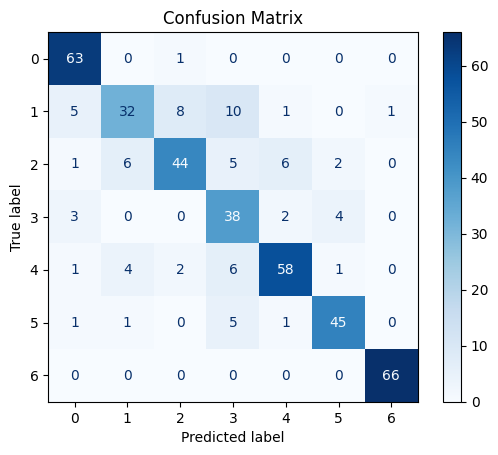

              precision    recall  f1-score   support

           0       0.85      0.98      0.91        64
           1       0.74      0.56      0.64        57
           2       0.80      0.69      0.74        64
           3       0.59      0.81      0.68        47
           4       0.85      0.81      0.83        72
           5       0.87      0.85      0.86        53
           6       0.99      1.00      0.99        66

    accuracy                           0.82       423
   macro avg       0.81      0.81      0.81       423
weighted avg       0.82      0.82      0.82       423

0.817966903073286
Overfit test, Accuracy: 0.9283175355450237


In [121]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#Best Parameters: {'activation': 'tanh', 'alpha': 0.1, 'batch_size': 512, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate_init': 0.001, 'n_iter_no_change': 50, 'solver': 'adam', 'tol': 0.0001}

bestModel = MLPClassifier(
            solver='adam', 
            alpha=0.1, 
            hidden_layer_sizes=(256, 128, 64), 
            activation='tanh', 
            max_iter=1000,
            tol=0.0001,
            learning_rate_init=0.001,
            n_iter_no_change=50, 
            batch_size=512,
            early_stopping=True)
            #verbose=True)

#Train the model
bestModel.fit(xMLPTrainingData, yMLPTrainingData)

#Predict using the testing data
bestPredictions = bestModel.predict(xMLPTestingData)

#Compute the accuracy scores
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

createConfusionMatrix(yMLPTestingData, bestPredictions)

#Print accuracy to test overfitting
print(bestAccuracy)

#Print accuracy to test overfitting
OverfitTest = bestModel.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)

Clear signs of overfitting for my Adam solver model

Best SGD solver Model using the parameters from the GridSearchCV

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


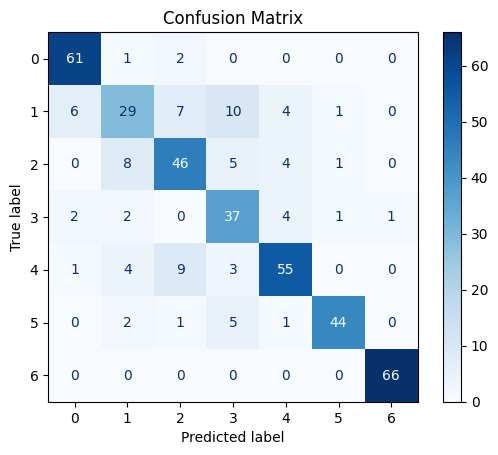

              precision    recall  f1-score   support

           0       0.87      0.95      0.91        64
           1       0.63      0.51      0.56        57
           2       0.71      0.72      0.71        64
           3       0.62      0.79      0.69        47
           4       0.81      0.76      0.79        72
           5       0.94      0.83      0.88        53
           6       0.99      1.00      0.99        66

    accuracy                           0.80       423
   macro avg       0.79      0.79      0.79       423
weighted avg       0.80      0.80      0.80       423

0.7990543735224587
Overfit test, Accuracy: 0.9703791469194313


In [122]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#Best parameters {'activation': 'relu', 'alpha': 0.1, 'batch_size': 32, 'hidden_layer_sizes': (256, 128, 64), 'learning_rate': 'adaptive', 'learning_rate_init': 0.1, 'n_iter_no_change': 50, 'solver': 'sgd', 'tol': 0.0001}

sgdBestModel = MLPClassifier(
    solver='sgd', 
    activation='relu', 
    alpha=0.1, 
    batch_size=32, 
    hidden_layer_sizes=(256, 128, 64), 
    learning_rate='adaptive', 
    learning_rate_init=0.1, 
    n_iter_no_change=50, 
    max_iter=1000, 
    early_stopping=True)

#Train the model
sgdBestModel.fit(xMLPTrainingData, yMLPTrainingData)

#Predict using the testing data
bestPredictions = sgdBestModel.predict(xMLPTestingData)

#Compute the accuracy scores
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

createConfusionMatrix(yMLPTestingData, bestPredictions)

#Print the test accuracy
print(bestAccuracy)

#Print the training accuracy to test for overfitting.
OverfitTest = sgdBestModel.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)

I believe at this point, that every model with the parameters provided to me through the GridSearchCV is overfitting. I will be altering my parmeters and perform another grid search with only parameters that won't cause overfitting. These parameters will greatly reduce the complexity of the model. Per the below references adjust network architecture, batch normalization, activation function options and other suggestions.

Reference: https://eureka.patsnap.com/report-how-to-reduce-overfitting-in-multilayer-perceptrons

In the below cells I use smaller hidden layer numbers and lengths, reduce the alpha value, force a smaller batch size, and reduce the number of iterations allowed as well as other small adjustments. After the cell for each individual solver there is then a cell using Bagging Classifier to run the model 100 times with bootstrapping and average the results so I can finally decide on the best optimizer and model to work with.

Try a GridSearchCV with the adam optimizer using parameters to reduce overfitting

In [123]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#Set reduced parameters to test 
adamParameters = {
    'hidden_layer_sizes': [(16,), (14,), (8, 4, 2), (16, 8), (12, 4), (6, 6)], #Large hidden layers contributed to overfitting
    'activation': ['relu', 'logistic', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.01, 0.1, 1], #increased alpha to prevent overfitting
    'batch_size': [32], #removed large batchsizes to prevent overfitting
    'learning_rate_init': [0.001, 0.1],
    'tol': [0.0001, 0.1],
    'n_iter_no_change': [10] #Higher value contributed to overfitting
}

#Set hard coded parameters for the mode, these parameters are not ment to change. Early stop resolves overfitting issues.
gridSearchAdam = MLPClassifier(max_iter=500, early_stopping=True) #reduced max epoch to prevent overfitting

#Default cross validation is 5
#The default scoring metric from MLPClassifier is used, this metric is Accuracy which should be acceptable as the classes are all similar sizes
adamGridModel = GridSearchCV(gridSearchAdam, adamParameters, n_jobs=-4, verbose=True)

#Parameter testing starts here
adamGridModel.fit(xMLPTrainingData, yMLPTrainingData)

#Prints the paramters and their accuracy
print("Best Parameters:", adamGridModel.best_params_)
print("Best Accuracy Score:", adamGridModel.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'activation': 'logistic', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.1, 'n_iter_no_change': 10, 'solver': 'adam', 'tol': 0.0001}
Best Accuracy Score: 0.6795164433831404


Run the MLP Classifier model with the adam solver and the best parameters found in the cell above. Implement baggingClassifier to take the average metrics when the model is ran 100 times.

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


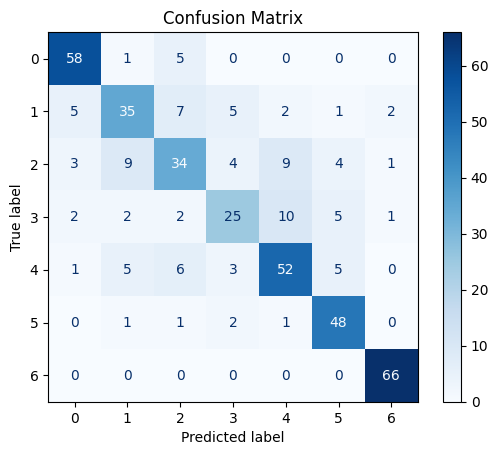

              precision    recall  f1-score   support

           0       0.84      0.91      0.87        64
           1       0.66      0.61      0.64        57
           2       0.62      0.53      0.57        64
           3       0.64      0.53      0.58        47
           4       0.70      0.72      0.71        72
           5       0.76      0.91      0.83        53
           6       0.94      1.00      0.97        66

    accuracy                           0.75       423
   macro avg       0.74      0.74      0.74       423
weighted avg       0.74      0.75      0.75       423

0.75177304964539
Overfit test, Accuracy: 0.784952606635071


In [124]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

#{'activation': 'logistic', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.1, 'n_iter_no_change': 10, 'solver': 'adam', 'tol': 0.0001}

adamBestModel = MLPClassifier(
            solver='adam', 
            alpha=0.01, 
            hidden_layer_sizes=(16,), 
            activation='logistic', 
            max_iter=500,
            tol=0.0001,
            learning_rate_init=0.1,
            n_iter_no_change=10, 
            batch_size=32,
            early_stopping=True)
            #verbose=True)

#Runs the model n times (100) and takes the average, does bootstrapping
adamBagger = BaggingClassifier(estimator=adamBestModel, n_estimators=100).fit(xMLPTrainingData, yMLPTrainingData)

#Use the average for the predictions
bestPredictions = adamBagger.predict(xMLPTestingData)

#Compute the accuracy
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

#Compute the rest of the metrics
createConfusionMatrix(yMLPTestingData, bestPredictions)

print(bestAccuracy)

#Print training accuracy to test for overfitting
OverfitTest = adamBagger.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)

For the Adam solver there is no longer a clear sign of overfitting.

Try a GridSearchCV with the sgd optimizer using parameters to reduce overfitting

In [125]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html

#Set parameters to test
#I had to drastically reduce my parameters to try and prevent overfitting
SGDparameters = {
    'hidden_layer_sizes': [(16,), (14,), (8, 4, 2), (16, 8), (12, 4), (6, 6)], #reduced to prevent overfitting
    'activation': ['relu', 'logistic', 'tanh'],
    'learning_rate': ['constant', 'adaptive'],
    'solver': ['sgd'],
    'alpha': [0.01, 0.1, 1],
    'batch_size': [32], #reduced to prevent overfitting
    'learning_rate_init': [0.001, 0.1],
    'tol': [0.0001, 0.1],
    'n_iter_no_change': [10] #reduced to prevent overfitting
}

#Set hard coded parameters for the mode, these parameters are not ment to change. Early stop resolves overfitting issues.
SGDgridSearchMLPNN = MLPClassifier(max_iter=500, early_stopping=True)

#Default cross validation is 5
#The default scoring metric from MLPClassifier is used, this metric is Accuracy which should be acceptable as the classes are all similar sizes
SGDgridModel = GridSearchCV(SGDgridSearchMLPNN, SGDparameters, n_jobs=-4, verbose=True)

#Parameter testing starts here
SGDgridModel.fit(xMLPTrainingData, yMLPTrainingData)

#Print the best paramters and their accuracy
print("Best Parameters:", SGDgridModel.best_params_)
print("Best Accuracy Score:", SGDgridModel.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.1, 'batch_size': 32, 'hidden_layer_sizes': (16, 8), 'learning_rate': 'adaptive', 'learning_rate_init': 0.1, 'n_iter_no_change': 10, 'solver': 'sgd', 'tol': 0.0001}
Best Accuracy Score: 0.719774199778765


Run the MLP Classifier model with the sgd solver and the best parameters found in the cell above. Implement baggingClassifier to take the average metrics when the model is ran 100 times.

In [126]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

#{'activation': 'tanh', 'alpha': 0.1, 'batch_size': 32, 'hidden_layer_sizes': (16, 8), 'learning_rate': 'adaptive', 'learning_rate_init': 0.1, 'n_iter_no_change': 10, 'solver': 'sgd', 'tol': 0.0001}
SGDbestModel = MLPClassifier(
            solver='sgd', 
            alpha=0.1, 
            hidden_layer_sizes=(16, 8), 
            activation='tanh', 
            max_iter=500,
            learning_rate='adaptive',
            tol=0.0001,
            learning_rate_init=0.1,
            n_iter_no_change=10, 
            batch_size=32,
            early_stopping=True)
            #verbose=True)

#Runs the model n times (100) and takes the average, does bootstrapping
SGDbestModel = BaggingClassifier(estimator=bestModel, n_estimators=5).fit(xMLPTrainingData, yMLPTrainingData)

#Get the predictions using the averages
bestPredictions = SGDbestModel.predict(xMLPTestingData)

#Compute the accuracy
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

#createConfusionMatrix(yMLPTestingData, bestPredictions)

print(bestAccuracy)

#Overfitting test
OverfitTest = SGDbestModel.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)

0.7848699763593381
Overfit test, Accuracy: 0.9235781990521327


The SGD Solver is still showing clear signs of overfitting even with the reduced parameters.

Try a GridSearchCV with the lbfgs optimizer using parameters to reduce overfitting

In [127]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
#Reference: https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/

#Set parameters to test with reduced metrics
LBFGSparameters = {
    'hidden_layer_sizes': [(16, ), (14, ), (8, 4, 2), (16, 8), (12, 4), (6, 6)], #reduced to prevent overfitting
    'activation': ['relu', 'logistic', 'tanh'],
    'solver': ['lbfgs'],
    'tol': [0.0001, 0.1],
    'alpha': [0.01, 0.1, 1],
    'max_fun': [15000, 150000]
}

#Set hard coded parameters for the mode, these parameters are not ment to change. Early stop resolves overfitting issues.
LBFGSgridSearchMLPNN = MLPClassifier(max_iter=500) #reduced to prevent overfitting

#Default cross validation is 5
#The default scoring metric from MLPClassifier is used, this metric is Accuracy which should be acceptable as the classes are all similar sizes
LBFGSgridModel = GridSearchCV(LBFGSgridSearchMLPNN, LBFGSparameters, n_jobs=-4, verbose=True)

#Parameter testing starts here
LBFGSgridModel.fit(xMLPTrainingData, yMLPTrainingData)

#Print the best paramters and their accuracy
print("Best Parameters:", LBFGSgridModel.best_params_)
print("Best Accuracy Score:", LBFGSgridModel.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best Parameters: {'activation': 'logistic', 'alpha': 1, 'hidden_layer_sizes': (14,), 'max_fun': 150000, 'solver': 'lbfgs', 'tol': 0.0001}
Best Accuracy Score: 0.7405158639580004


Run the MLP Classifier model with the lbfgs solver and the best parameters found in the cell above. Implement baggingClassifier to take the average metrics when the model is ran 100 times.

In [128]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

#{'activation': 'logistic', 'alpha': 0.5, 'hidden_layer_sizes': (16, 8), 'max_fun': 15000, 'solver': 'lbfgs', 'tol': 0.0001}

LBFGSbestModel = MLPClassifier(
            solver='lbfgs', 
            alpha=0.5, 
            hidden_layer_sizes=(16, 8), 
            activation='logistic', 
            max_iter=500,
            tol=0.0001,
            max_fun=15000)
            #verbose=True)

#Runs the model n times (100) and takes the average, does bootstrapping
LBFGSbestModel = BaggingClassifier(estimator=bestModel, n_estimators=100).fit(xMLPTrainingData, yMLPTrainingData)

#Predict using the averaged data
bestPredictions = LBFGSbestModel.predict(xMLPTestingData)

#Compute the accuracy using the averaged data
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

#createConfusionMatrix(yMLPTestingData, bestPredictions)

#lbfgs does not have a loss curve attribute to print

print(bestAccuracy)

#Overfitting Test
OverfitTest = LBFGSbestModel.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)

0.7966903073286052
Overfit test, Accuracy: 0.8963270142180095


The lbfgs solver still shows signs of overfitting even with the reduced parameters.

Still, after all of my efforts the only model not experiencing overfitting is the adam solver. As this model didn't overfit and I want to make sure that this model could be used on unseen data collected from other geographic locations, I am selcting the adam solver model as the best model.

This is the best model I was able to produce:

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


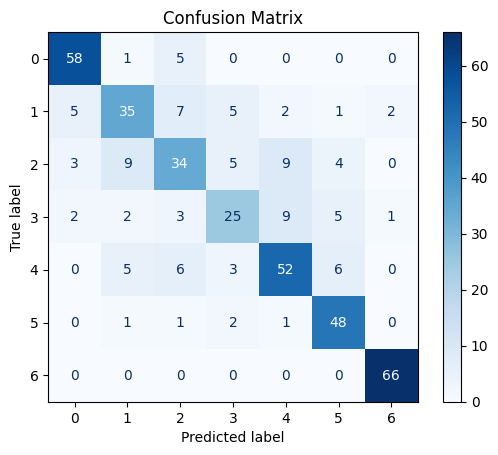

              precision    recall  f1-score   support

           0       0.85      0.91      0.88        64
           1       0.66      0.61      0.64        57
           2       0.61      0.53      0.57        64
           3       0.62      0.53      0.57        47
           4       0.71      0.72      0.72        72
           5       0.75      0.91      0.82        53
           6       0.96      1.00      0.98        66

    accuracy                           0.75       423
   macro avg       0.74      0.74      0.74       423
weighted avg       0.74      0.75      0.75       423

0.75177304964539
Overfit test, Accuracy: 0.7808056872037915


In [135]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

#{'activation': 'logistic', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.1, 'n_iter_no_change': 10, 'solver': 'adam', 'tol': 0.0001}

adamBestModel = MLPClassifier(
            solver='adam', 
            alpha=0.01, 
            hidden_layer_sizes=(16,), 
            activation='logistic', 
            max_iter=500,
            tol=0.0001,
            learning_rate_init=0.1,
            n_iter_no_change=10, 
            batch_size=32,
            early_stopping=True)
            #verbose=True)

#Runs the model n times (100) and takes the average, does bootstrapping
adamBagger = BaggingClassifier(estimator=adamBestModel, n_estimators=100).fit(xMLPTrainingData, yMLPTrainingData)

#Use the average for the predictions
bestPredictions = adamBagger.predict(xMLPTestingData)

#Compute the accuracy
bestAccuracy = accuracy_score(yMLPTestingData, bestPredictions)

#Compute the rest of the metrics
createConfusionMatrix(yMLPTestingData, bestPredictions)

#lbfgs does not have a loss curve attribute to print

print(bestAccuracy)

#Print training accuracy to test for overfitting
OverfitTest = adamBagger.predict(xMLPTrainingData)
OverfitAccuracy = accuracy_score(yMLPTrainingData, OverfitTest)
print("Overfit test, Accuracy:", OverfitAccuracy)

Other / Mis. tests

Create Heat Maps for Paper / Report

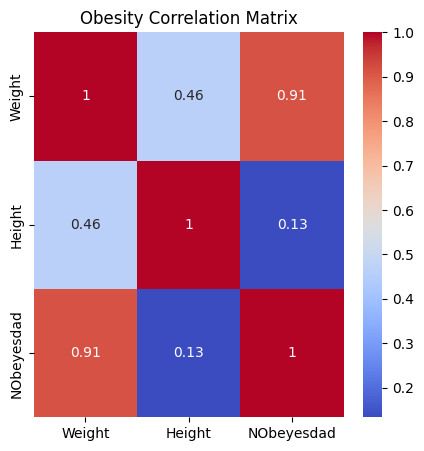

In [130]:
#Reference 4: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/

#Create the correlation matrix using the encoded and feature scaled data.
test = ObesityDataSetCsv[['Weight', 'Height', 'NObeyesdad']]
#test = ObesityDataSetCsv[['Weight', 'Height', 'NObeyesdad', 'MTRANS_Public_Transportation', 'MTRANS_Automobile']]
correlationMatrix = test.corr()

#The figure has to be large because there are 32 features
plt.figure(figsize=(5,5))
sns.heatmap(correlationMatrix, annot=True, cmap="coolwarm")
plt.title("Obesity Correlation Matrix")
plt.show()

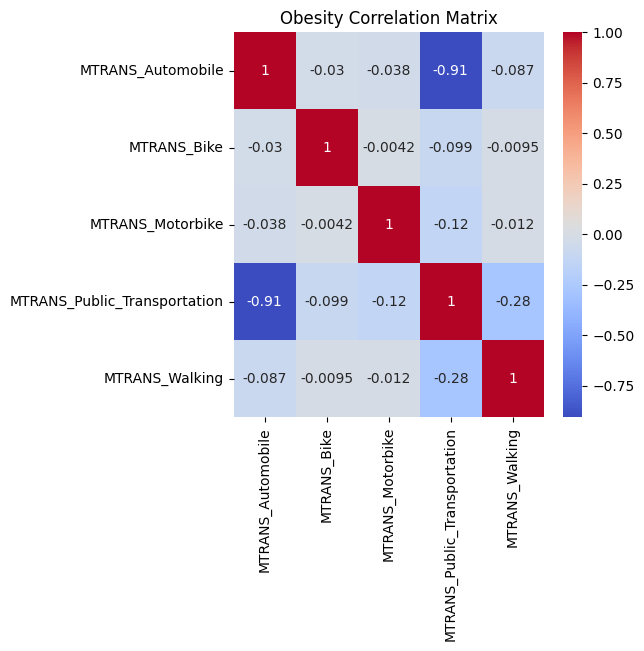

In [131]:
#Reference 4: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/

#Create the correlation matrix using the encoded and feature scaled data.
test = ObesityDataSetCsv[['MTRANS_Automobile','MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']]
#test = ObesityDataSetCsv[['Weight', 'Height', 'NObeyesdad', 'MTRANS_Public_Transportation', 'MTRANS_Automobile']]
correlationMatrix = test.corr()

#The figure has to be large because there are 32 features
plt.figure(figsize=(5,5))
sns.heatmap(correlationMatrix, annot=True, cmap="coolwarm")
plt.title("Obesity Correlation Matrix")
plt.show()

Find what features contribute most to the best model

In [132]:
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html

mostImportantFeatures = permutation_importance(adamBagger, xMLPTestingData, yMLPTestingData, n_repeats=10)

#These results are UGLY, there is an importance output for each of the 17 features being used. Each of the 17 features
#has 10 values, 1 for each of the n_repeats above. These values are used to create the mean. I will use the mean to decide
#What feature is best.
print(xMLPTestingData.columns)
print(mostImportantFeatures.importances_mean)

Index(['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC',
       'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation',
       'MTRANS_Walking'],
      dtype='str')
[ 0.19432624  0.18699764  0.09858156  0.0212766   0.12364066  0.10803783
  0.13144208  0.00023641  0.04609929  0.00732861  0.03451537  0.02009456
  0.12836879 -0.00023641  0.          0.02458629 -0.00070922]


Test MinMaxScalar on best model to prove it produces reduced metrics by around 6 points in everything. This is a copy of the above code, unfortuanntly the scaler is used relatively early in the process and the original pandas dataframe has already been altered so I need to make a new one.

Multiclass Entries:
 0: Insufficient_Weight
 1: Normal_Weight
 2: Overweight_Level_I
 3: Overweight_Level_II
 4: Obesity_Type_I
 5: Obesity_Type_II
 6: Obesity_Type_III


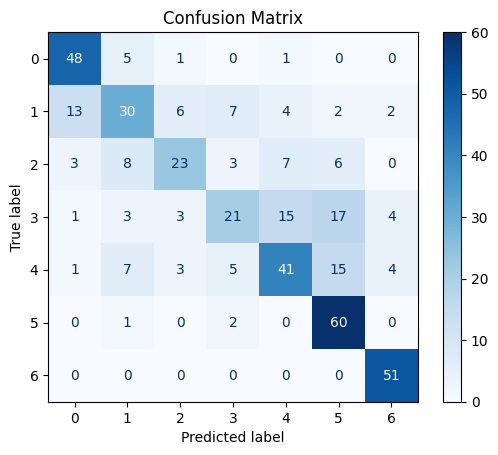

              precision    recall  f1-score   support

           0       0.73      0.87      0.79        55
           1       0.56      0.47      0.51        64
           2       0.64      0.46      0.53        50
           3       0.55      0.33      0.41        64
           4       0.60      0.54      0.57        76
           5       0.60      0.95      0.74        63
           6       0.84      1.00      0.91        51

    accuracy                           0.65       423
   macro avg       0.64      0.66      0.64       423
weighted avg       0.64      0.65      0.63       423

0.6477541371158393
Overfit test, Accuracy: 0.6771327014218009


In [133]:
#Reference: https://www.geeksforgeeks.org/python/python-os-getcwd-method/
#Read the obesity dataset and assign it to a variable
ObesityDataSetCsvMinMaxTest = pd.read_csv(path)

#Reference: https://www.geeksforgeeks.org/python/how-to-convert-categorical-variable-to-numeric-in-pandas/
#Reference: https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/

#Everything needs converted into a float/int in order to work with the models being built
#I will set all of the binary features to 0 and 1. The change is permenant
ObesityDataSetCsvMinMaxTest['Gender'] = ObesityDataSetCsvMinMaxTest['Gender'].replace(['Female', 'Male'], [0, 1])
ObesityDataSetCsvMinMaxTest['family_history_with_overweight'] = ObesityDataSetCsvMinMaxTest['family_history_with_overweight'].replace(['no', 'yes'], [0, 1])
ObesityDataSetCsvMinMaxTest['FAVC'] = ObesityDataSetCsvMinMaxTest['FAVC'].replace(['no', 'yes'], [0, 1])
ObesityDataSetCsvMinMaxTest['SMOKE'] = ObesityDataSetCsvMinMaxTest['SMOKE'].replace(['no', 'yes'], [0, 1])
ObesityDataSetCsvMinMaxTest['SCC'] = ObesityDataSetCsvMinMaxTest['SCC'].replace(['no', 'yes'], [0, 1])

#Set the ordered features from 0 ~ # where 0 is the lowest instance of the feature
ObesityDataSetCsvMinMaxTest['CAEC'] = ObesityDataSetCsvMinMaxTest['CAEC'].replace(['no', 'Sometimes', 'Frequently', 'Always'], [0, 1, 2, 3])
ObesityDataSetCsvMinMaxTest['CALC'] = ObesityDataSetCsvMinMaxTest['CALC'].replace(['no', 'Sometimes', 'Frequently', 'Always'], [0, 1, 2, 3])
#Convert the target class
ObesityDataSetCsvMinMaxTest['NObeyesdad'] = ObesityDataSetCsvMinMaxTest['NObeyesdad'].replace(['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 
                                                                           'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III'], [0, 1, 2, 3, 4, 5, 6])

#Uses One Hot Encoding, this splits the categorical data into individual binary colums where 1 is if that column was true and 0 for all other options.
ObesityDataSetCsvMinMaxTest = pd.get_dummies(ObesityDataSetCsvMinMaxTest, columns=['MTRANS'], dtype=int)


#Reference: https://www.geeksforgeeks.org/pandas/python-scaling-numbers-column-by-column-with-pandas/
#Reference: https://www.geeksforgeeks.org/machine-learning/standardscaler-minmaxscaler-and-robustscaler-techniques-ml/

#This is the scaler we will be applying to the data, from my understanding this scaler is best for Logistic Regression and Neural Networks. Both used in this code.
#Scales the data around 0 with standard deviation of 1.
scalerInstance = MinMaxScaler()

#Only non binary columns need to be scaled {Age, Height, Weight, FCVC, NCP, CAEC, CH2O, FAF, TUE, CALC}
#These are the remianing features that have not gone through encoding in the previous cell
ObesityDataSetCsvMinMaxTest[["Age", "Height", "Weight", "FCVC", "NCP", "CAEC", "CH2O", "FAF", "TUE", "CALC"]] = scalerInstance.fit_transform(
    ObesityDataSetCsvMinMaxTest[["Age", "Height", "Weight", "FCVC", "NCP", "CAEC", "CH2O", "FAF", "TUE", "CALC"]])


#Reference: https://www.geeksforgeeks.org/machine-learning/how-to-split-a-dataset-into-train-and-test-sets-using-python/
#Reference: https://www.geeksforgeeks.org/python/python-pandas-dataframe-astype/
#Reference: https://stackoverflow.com/questions/48841624/dataframe-object-has-no-attribute-ravel-when-transforming-target-variable
#Training data encoding/normalizing was perforemd earlier and will not be done again. I will be using that same dataframe. The class has not been converted to int this time and needs done again.

#Features dropped weight, height, MTRANS_Automobile
MLPFeaturesTest = ObesityDataSetCsvMinMaxTest[["Gender", "Age", "family_history_with_overweight", "FAVC", "FCVC", "NCP", "CAEC", "SMOKE", "CH2O", "SCC", 
                              "FAF", "TUE", "CALC", "MTRANS_Bike", "MTRANS_Motorbike", "MTRANS_Public_Transportation", "MTRANS_Walking"]]
#Target Classes
MLPClassTest = ObesityDataSetCsvMinMaxTest[["NObeyesdad"]]

#print(features.dtypes) Gender, Family_history_with_overweight, FAVC, SMOKE, SCC are all registering as type object and need to be convereted for the models to run properly
MLPFeaturesTest["Gender"] = MLPFeaturesTest["Gender"].astype(int)
MLPFeaturesTest["family_history_with_overweight"] = MLPFeaturesTest["family_history_with_overweight"].astype(int)
MLPFeaturesTest["FAVC"] = MLPFeaturesTest["FAVC"].astype(int)
MLPFeaturesTest["SMOKE"] = MLPFeaturesTest["SMOKE"].astype(int)
MLPFeaturesTest["SCC"] = MLPFeaturesTest["SCC"].astype(int)

#The type needs set as an int. Even though there are only integers in the column, the column itself stayed labeled as an object
MLPClassTest = MLPClassTest.astype(int)

#Create the train test split for the dataset 80 / 20 split.
xMLPTrainingDataTest, xMLPTestingDataTest, yMLPTrainingDataTest, yMLPTestingDataTest = train_test_split(MLPFeaturesTest, MLPClassTest, test_size=0.2, shuffle=True)

#Converts the data from a 2D dataframe to a 1D list
yMLPTrainingDataTest = yMLPTrainingDataTest.values.ravel()
yMLPTestingDataTest = yMLPTestingDataTest.values.ravel()

#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
#Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html

#{'activation': 'logistic', 'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.1, 'n_iter_no_change': 10, 'solver': 'adam', 'tol': 0.0001}

adamBestModel = MLPClassifier(
            solver='adam', 
            alpha=0.01, 
            hidden_layer_sizes=(16,), 
            activation='logistic', 
            max_iter=500,
            tol=0.0001,
            learning_rate_init=0.1,
            n_iter_no_change=10, 
            batch_size=32,
            early_stopping=True)
            #verbose=True)

#Runs the model n times (100) and takes the average, does bootstrapping
adamBaggerTest = BaggingClassifier(estimator=adamBestModel, n_estimators=100).fit(xMLPTrainingDataTest, yMLPTrainingDataTest)

#Use the average for the predictions
bestPredictionsTest = adamBaggerTest.predict(xMLPTestingDataTest)

#Compute the accuracy
bestAccuracyTest = accuracy_score(yMLPTestingDataTest, bestPredictionsTest)

#Compute the rest of the metrics
createConfusionMatrix(yMLPTestingDataTest, bestPredictionsTest)

#lbfgs does not have a loss curve attribute to print

print(bestAccuracyTest)

#Print training accuracy to test for overfitting
OverfitTestTest = adamBaggerTest.predict(xMLPTrainingDataTest)
OverfitAccuracyTest = accuracy_score(yMLPTrainingDataTest, OverfitTestTest)
print("Overfit test, Accuracy:", OverfitAccuracyTest)

As you can see the metrics are around 6 points less then my best adam model using the standard scaler/